Data Profiling, Cleaning and Analysis

importing header files

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import warnings
import os
os.makedirs('output', exist_ok=True)
warnings.filterwarnings('ignore')

Loading the Data Files

In [43]:
# Loadind all files
sales_data = pd.read_csv('data/Sales_Data.csv')
sales_people = pd.read_csv('data/Sales_People.csv')
customer_data = pd.read_csv('data/Customer_Data.csv')
fremont_rocket_company_employees = pd.read_excel(
    'data/Fremont_Rocket_Company_Employees.xlsx')
production_line_Invoice_data = pd.read_excel(
    'data/Production_Line_Invoice_Details.xlsx')
energy_prices_daily = pd.read_excel(
    'data/energy_prices_daily.xlsx')

Data Profiling

In [44]:
# Quick look at sales data
print(sales_data.shape)
print(sales_data.info())
print(sales_data.describe())
print(sales_data.isnull().sum())
print(sales_data.duplicated().sum())
print(sales_data.head())

(1439, 15)
<class 'pandas.DataFrame'>
RangeIndex: 1439 entries, 0 to 1438
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype
---  ------                               --------------  -----
 0   Sale Date                            1439 non-null   str  
 1   Year                                 1439 non-null   int64
 2   Sold By                              1439 non-null   str  
 3   Product                              1439 non-null   str  
 4   Revenue                              1439 non-null   int64
 5   Commission Paid                      1439 non-null   str  
 6   Paid To Address                      1439 non-null   str  
 7   Paid to                              1439 non-null   str  
 8   Date                                 1439 non-null   str  
 9   Customer                             1439 non-null   str  
 10  Fuel Type                            1439 non-null   str  
 11  Rocket Type                          1439 non-null   str

1. No null values and no duplicates — clean file
2. Sale Date stored as string: needs parsing to date
3. Commission Paid stored as string with $ signs: needs cleaning
4. Fuel Type and Rocket Type are identical columns: redundant, one can be dropped

In [45]:
# Quick look at production invoices
print(production_line_Invoice_data.shape)
print(production_line_Invoice_data.info())
print(production_line_Invoice_data.describe())
print(production_line_Invoice_data.isnull().sum())
print(production_line_Invoice_data.duplicated().sum())
print(production_line_Invoice_data.head())

(1399, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1399 entries, 0 to 1398
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          1399 non-null   int64  
 1   Model         1399 non-null   str    
 2   InvoiceID     1399 non-null   str    
 3   Description   1399 non-null   str    
 4   Amount        1399 non-null   float64
 5   EmployeeInfo  584 non-null    str    
 6   VendorInfo    815 non-null    str    
dtypes: float64(1), int64(1), str(5)
memory usage: 76.6 KB
None
              Year        Amount
count  1399.000000  1.399000e+03
mean   2045.395997  2.026034e+06
std       2.712054  1.179930e+06
min    2040.000000  8.307700e+02
25%    2043.000000  1.061435e+06
50%    2046.000000  1.981380e+06
75%    2048.000000  2.897147e+06
max    2049.000000  6.156817e+06
Year              0
Model             0
InvoiceID         0
Description       0
Amount            0
EmployeeInfo    815
VendorInfo      584
dtype: 

1. 1399 rows and 7 columns: one row per invoice
2. EmployeeInfo and VendorInfo are mutually exclusive
3. EmployeeInfo and VendorInfo stored as nested JSON
4. Year only: no exact invoice date available

In [46]:
# Quick look at sales people
print(sales_people.shape)
print(sales_people.info())
print(sales_people.describe())
print(sales_people.isnull().sum())
print(sales_people.duplicated().sum())
print(sales_people.head())

(10, 7)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Name           10 non-null     str  
 1   DOB            10 non-null     int64
 2   Sales Person   10 non-null     str  
 3   Address        10 non-null     str  
 4   Email Address  10 non-null     str  
 5   Phone Number   10 non-null     str  
 6   Sales Region   10 non-null     str  
dtypes: int64(1), str(6)
memory usage: 692.0 bytes
None
               DOB
count    10.000000
mean   2006.000000
std      15.070206
min    1977.000000
25%    1999.250000
50%    2002.000000
75%    2020.000000
max    2026.000000
Name             0
DOB              0
Sales Person     0
Address          0
Email Address    0
Phone Number     0
Sales Region     0
dtype: int64
0
              Name   DOB     Sales Person  \
0  Chase Armstrong  2001  Chase Armstrong   
1      Nova Kepler  2023      Nova Kepler   
2      Orion B

1. Only 10 salespeople in the dataset
2. DOB stored as year only, inconsistent with production data which has full dates
3. Sales Person column is identical to Name column: can be dropped
5. All personal email addresses
6. No null values and no duplicates

In [47]:
# Quick look at customers
print(customer_data.shape)
print(customer_data.info())
print(customer_data.describe())
print(customer_data.isnull().sum())
print(customer_data.duplicated().sum())
print(customer_data.head())

(7, 6)
<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Organization       7 non-null      str  
 1   Address            7 non-null      str  
 2   Founded            7 non-null      int64
 3   Contact Person     7 non-null      str  
 4   Phone Number       7 non-null      str  
 5   Industry/Category  7 non-null      str  
dtypes: int64(1), str(5)
memory usage: 468.0 bytes
None
           Founded
count     7.000000
mean   1974.714286
std      40.065423
min    1916.000000
25%    1950.500000
50%    1979.000000
75%    1993.500000
max    2040.000000
Organization         0
Address              0
Founded              0
Contact Person       0
Phone Number         0
Industry/Category    0
dtype: int64
0
                 Organization  \
0  U.S. Department of Defense   
1                      Amazon   
2             Pagliacci Pizza   
3             Dick's Dri

1. Only 7 customers in the dataset
2. No null values and no duplicates
3. No unique customer ID exists

In [48]:
# Quick look at employees
print(fremont_rocket_company_employees.shape)
print(fremont_rocket_company_employees.info())
print(fremont_rocket_company_employees.describe())
print(fremont_rocket_company_employees.isnull().sum())
print(fremont_rocket_company_employees.duplicated().sum())
print(fremont_rocket_company_employees.head())

(100, 8)
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           100 non-null    str   
 1   DOB            100 non-null    int64 
 2   Job Title      100 non-null    str   
 3   Department     100 non-null    str   
 4   Employee ID    100 non-null    int64 
 5   Address        100 non-null    str   
 6   Email Address  100 non-null    str   
 7   Phone Number   100 non-null    object
dtypes: int64(2), object(1), str(5)
memory usage: 6.4+ KB
None
              DOB  Employee ID
count   100.00000   100.000000
mean   2000.19000  1050.500000
std       8.54187    29.011492
min    1986.00000  1001.000000
25%    1994.00000  1025.750000
50%    1999.00000  1050.500000
75%    2005.00000  1075.250000
max    2026.00000  1100.000000
Name             0
DOB              0
Job Title        0
Department       0
Employee ID      0
Address          0
Email Address

2. DOB stored as year only — inconsistent with production invoice data which has full dates, two different HR systems clearly in use
3. Employee ID is numeric format 1001 to 1100 — completely different from production worker IDs
5. Phone numbers in inconsistent formats
6. No null values and no duplicates
7. Salespeople exist in both the employees table 

In [49]:
# Quick look at energy prices
print(energy_prices_daily.shape)
print(energy_prices_daily.info())
print(energy_prices_daily.describe())
print(energy_prices_daily.isnull().sum())
print(energy_prices_daily.duplicated().sum())
print(energy_prices_daily.head())

(6210, 5)
<class 'pandas.DataFrame'>
RangeIndex: 6210 entries, 0 to 6209
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   6210 non-null   datetime64[us]
 1   Liquid_Hydrogen_Price  6210 non-null   float64       
 2   APCP_Price             6210 non-null   float64       
 3   Uranium_235_Price      6210 non-null   float64       
 4   Forecast_Source        6210 non-null   str           
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 242.7 KB
None
                      Date  Liquid_Hydrogen_Price   APCP_Price  \
count                 6210            6210.000000  6210.000000   
mean   2048-07-01 12:00:00             113.173398   167.739622   
min    2040-01-01 00:00:00              69.710000   102.210000   
25%    2044-04-01 06:00:00              87.512500   138.597500   
50%    2048-07-01 12:00:00              98.150000   170.635000   
75%    2052-

1. Three fuel types tracked daily
3. Date already parsed as datetime
4. No null values and no duplicates
5. Three forecast types in data: Historical, FCT, Projection
6. This is external reference data — not generated by Fremont Rocket Company, stored separately from operational tables

CLEANING SALES_DATA

In [50]:
# Make a copy so original is untouched
sales = sales_data.copy()

# Clean column names
# Remove spaces, lowercase, replace spaces with underscore
sales.columns = sales.columns.str.strip()\
    .str.lower()\
    .str.replace(' ', '_')

# Clean revenue — already numeric but force it
sales['revenue'] = pd.to_numeric(
    sales['revenue'], errors='coerce')

# Clean commission — has $ and commas
# Example: $690,547 → 690547
sales['commission_paid'] = sales['commission_paid']\
    .str.replace('[\$,]', '', regex=True)\
    .str.strip()\
    .pipe(pd.to_numeric, errors='coerce')

# Parse sale date
sales['sale_date'] = pd.to_datetime(
    sales['sale_date'], errors='coerce')

# Calculate commission rate per sale
sales['commission_rate_pct'] = (
    sales['commission_paid'] /
    sales['revenue'] * 100
).round(2)

# Quick check
print("Sales data cleaned")
print(f"Shape: {sales.shape}")
print(f"\nColumn names: {sales.columns.tolist()}")
print(f"\nSample:")
print(sales[['sale_date', 'product',
    'revenue', 'commission_paid',
    'commission_rate_pct']].head())

Sales data cleaned
Shape: (1439, 16)

Column names: ['sale_date', 'year', 'sold_by', 'product', 'revenue', 'commission_paid', 'paid_to_address', 'paid_to', 'date', 'customer', 'fuel_type', 'rocket_type', 'payload_(metric_tones)', 'fuel_consumption_(in_metric_tonnes)', 'est._lifetime_(#_launches)', 'commission_rate_pct']

Sample:
   sale_date     product   revenue  commission_paid  commission_rate_pct
0 2040-01-06  Atomic Eve   6905470           690547                 10.0
1 2040-02-12  Atomic Eve  10811151           540558                  5.0
2 2040-02-23  Atomic Eve  11320630           679238                  6.0
3 2040-04-27  Atomic Eve  11266653           450666                  4.0
4 2040-08-03  Atomic Eve  11372020           454881                  4.0


CLEANING PRODUCTION INVOICE LINE DATA

In [51]:
# Make a copy
production = production_line_Invoice_data.copy()

# Clean column names
production.columns = production.columns\
    .str.strip()\
    .str.lower()\
    .str.replace(' ', '_')

# Clean amount — remove $ and commas
production['amount'] = pd.to_numeric(
    production['amount'].astype(str)
    .str.replace('[\$,]', '', regex=True),
    errors='coerce')

# Extract vendor info from nested JSON
def extract_vendor(val):
    try:
        if pd.isna(val):
            return pd.Series({
                'vendor_id': None,
                'vendor_name': None})
        v = json.loads(str(val))
        return pd.Series({
            'vendor_id': v.get('VendorID'),
            'vendor_name': v.get('VendorName')})
    except:
        return pd.Series({
            'vendor_id': None,
            'vendor_name': None})

# Extract employee info from nested JSON
def extract_employee(val):
    try:
        if pd.isna(val):
            return pd.Series({
                'emp_name': None,
                'emp_id': None,
                'emp_title': None})
        e = json.loads(str(val))
        return pd.Series({
            'emp_name': e.get('Name'),
            'emp_id': e.get('Employee ID'),
            'emp_title': e.get('Job Title')})
    except:
        return pd.Series({
            'emp_name': None,
            'emp_id': None,
            'emp_title': None})

# Apply extractions
vendor_cols = production['vendorinfo']\
    .apply(extract_vendor)
emp_cols = production['employeeinfo']\
    .apply(extract_employee)

production = pd.concat(
    [production, vendor_cols, emp_cols],
    axis=1)

# Display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("Production data cleaned")
print(f"Shape: {production.shape}")
print(f"\nColumns: {production.columns.tolist()}")
print(f"\nSample:")
print(production.head(10))

Production data cleaned
Shape: (1399, 12)

Columns: ['year', 'model', 'invoiceid', 'description', 'amount', 'employeeinfo', 'vendorinfo', 'vendor_id', 'vendor_name', 'emp_name', 'emp_id', 'emp_title']

Sample:
   year       model                             invoiceid  \
0  2040  Atomic Eve  3c00c249-5430-40d4-985b-5fd6271f771d   
1  2040  Atomic Eve  5e326401-0880-451b-9ca8-aeb1d9dd109e   
2  2040  Atomic Eve  4b3f88af-1112-4b21-9761-9bb5d4b561b5   
3  2040  Atomic Eve  aaa0cebc-2301-4d18-8c11-f626e0d098d0   
4  2040  Atomic Eve  3b8805c8-b46e-4fec-bfb3-a861d470b315   
5  2040  Atomic Eve  e44748fa-9268-46b8-8e72-69ea4c860cb2   
6  2040  Atomic Eve  ab93686b-a588-4784-9d36-8bc1d11b4cbc   
7  2040  Atomic Eve  e2584aee-cbb0-47c0-b24e-8f2c8367b8cb   
8  2040  Atomic Eve  b345e3a4-0a39-4c2a-849c-a0459da01101   
9  2040  Atomic Eve  67d1be21-7fb5-4bf0-be14-135c1c72f307   

                                         description      amount  \
0      Machine Maintenance - Orbital Components In

CLEANING SALES_PEOPLE DATA

In [52]:
# Clean Sales People
salespeople = sales_people.copy()

# Clean column names
salespeople.columns = salespeople.columns\
    .str.strip()\
    .str.lower()\
    .str.replace(' ', '_')

# Drop redundant column
# sales_person is identical to name
salespeople = salespeople.drop(
    columns=['sales_person'])

print("Sales People cleaned")
print(salespeople)

Sales People cleaned
              name   dob                                   address  \
0  Chase Armstrong  2001     1234 Evergreen Way, Seattle, WA 98101   
1      Nova Kepler  2023    987 Pinecrest Blvd, Bellevue, WA 98004   
2      Orion Blaze  2026        4567 Cascade Ave, Tacoma, WA 98402   
3      Luna Vector  1999         7890 Harbor St, Spokane, WA 99201   
4     Stella Ignis  2011        2345 Alder Lane, Redmond, WA 98052   
5     Jet Falconer  2003       6789 Maple Drive, Olympia, WA 98501   
6      Atlas Ryder  1997       1357 Rainier Rd, Kirkland, WA 98033   
7      Vega Zenith  2000          2468 Cedar St, Everett, WA 98201   
8    Cassio Skyler  2023  5678 Ridgeview Terrace, Renton, WA 98055   
9      Leo Rockett  1977     4321 Summit Ave, Bellingham, WA 98225   

               email_address    phone_number   sales_region  
0  chase.armstrong@email.com  (206) 555-0101  Seattle Metro  
1      nova.kepler@email.com  (425) 555-0102       Eastside  
2      orion.blaze@ema

CLEAN CUSTOMERS DATA

In [53]:
# Clean Customers
customers = customer_data.copy()

# Clean column names
customers.columns = customers.columns\
    .str.strip()\
    .str.lower()\
    .str.replace(' ', '_')

# Add customer ID since none exists
customers = customers.reset_index()\
    .rename(columns={'index': 'customer_id'})
customers['customer_id'] = \
    customers['customer_id'] + 1

print("Customers cleaned")
print(customers)

Customers cleaned
   customer_id                organization  \
0            1  U.S. Department of Defense   
1            2                      Amazon   
2            3             Pagliacci Pizza   
3            4             Dick's Drive-In   
4            5                      Boeing   
5            6               Sound Transit   
6            7        Armstrong Industrial   

                                             address  founded  \
0  1400 Defense Pentagon, Washington, D.C. 20301-...     1947   
1          410 Terry Avenue North, Seattle, WA 98109     1994   
2            423 East Pike Street, Seattle, WA 98122     1979   
3              111 NE 45th Street, Seattle, WA 98105     1954   
4       100 North Riverside Plaza, Chicago, IL 60606     1916   
5        401 South Jackson Street, Seattle, WA 98104     1993   
6                1234 Industrial Way, Kent, WA 98032     2040   

    contact_person    phone_number    industry/category  
0      John Keller  (703) 571-3343

CLEAN EMPLOYEES DATA

In [54]:
# Clean Employees
employees = fremont_rocket_company_employees.copy()

# Clean column names
employees.columns = employees.columns\
    .str.strip()\
    .str.lower()\
    .str.replace(' ', '_')

print("Employees cleaned")
print(f"Shape: {employees.shape}")
print(employees)

Employees cleaned
Shape: (100, 8)
                     name   dob            job_title   department  \
0          Daniel Hendrix  1990   Aerospace Engineer  Engineering   
1          Cynthia Monroe  1991  Mechanical Engineer  Engineering   
2   Christopher Alexander  1992  Mechanical Engineer  Engineering   
3            Alex Schmidt  1992   Compliance Officer        Legal   
4           Chelsea Ortiz  1992   Operations Manager   Operations   
..                    ...   ...                  ...          ...   
95            Aaron Smith  2005   Aerospace Engineer  Engineering   
96           Stella Ignis  2011          Salesperson        Sales   
97            Nova Kepler  2023          Salesperson        Sales   
98          Cassio Skyler  2023          Salesperson        Sales   
99            Orion Blaze  2026          Salesperson        Sales   

    employee_id                                            address  \
0          1064  24000 Krista Lakes Suite 879, New Christian, M... 

CLEAN ENERGY PRICES

In [55]:
# Clean Energy Prices
energy = energy_prices_daily.copy()

# Clean column names
energy.columns = energy.columns\
    .str.strip()\
    .str.lower()\
    .str.replace(' ', '_')

# Parse date
energy['date'] = pd.to_datetime(
    energy['date'], errors='coerce')

# Extract year
energy['year'] = energy['date'].dt.year

print("Energy Prices cleaned")
print(f"Shape: {energy.shape}")
print(f"Date range: {energy['date'].min()} "
    f"to {energy['date'].max()}")
print(f"\nHistorical vs Projection:")
print(energy['forecast_source'].value_counts())
print(f"\nSample:")
print(energy.head())

Energy Prices cleaned
Shape: (6210, 6)
Date range: 2040-01-01 00:00:00 to 2056-12-31 00:00:00

Historical vs Projection:
forecast_source
Historical    3653
Projection    1461
FCT           1096
Name: count, dtype: int64

Sample:
        date  liquid_hydrogen_price  apcp_price  uranium_235_price  \
0 2040-01-01                 163.98      119.77            1024.48   
1 2040-01-02                 167.68      119.69            1020.16   
2 2040-01-03                 168.24      123.59            1019.13   
3 2040-01-04                 165.22      119.39            1019.32   
4 2040-01-05                 164.60      114.37            1013.06   

  forecast_source  year  
0      Historical  2040  
1      Historical  2040  
2      Historical  2040  
3      Historical  2040  
4      Historical  2040  


ANALYSING SALES DATA

In [56]:

#How many rockets sold per year?
sales.groupby('year')['product'].count()

year
2040    150
2041    146
2042    141
2043    143
2044    149
2045    142
2046    151
2047    138
2048    141
2049    138
Name: product, dtype: int64

Sales volume is relatively flat, around 138 to 151 rockets per year
No dramatic growth or decline in total units

In [57]:
#Which models sold the most?
sales.groupby('product')['product'].count()\
    .sort_values(ascending=False)

product
Saturn 18      767
Titan 2043     290
Falcon 5000    288
Atomic Eve      61
Seattle EXP     33
Name: product, dtype: int64

What I see:
Saturn 18 is our best seller by far, 767 units total
Atomic Eve and Seattle EXP have very low sales
Falcon 5000 and Titan 2043 are growing replacements

In [58]:
#Revenue by year
sales.groupby('year')['revenue'].sum()

year
2040    266600540
2041    229115211
2042    243619567
2043    309726403
2044    317056826
2045    305362272
2046    333693084
2047    391113342
2048    414380889
2049    428283269
Name: revenue, dtype: int64

In [59]:
# Revenue is growing but by how much each year?
# Let me add year over year change to see the trend clearly

revenue_by_year = sales.groupby('year')['revenue'].sum().reset_index()

revenue_by_year['yoy_change_pct'] = revenue_by_year['revenue'].pct_change().mul(100).round(1)

print(revenue_by_year)

   year    revenue  yoy_change_pct
0  2040  266600540             NaN
1  2041  229115211           -14.1
2  2042  243619567             6.3
3  2043  309726403            27.1
4  2044  317056826             2.4
5  2045  305362272            -3.7
6  2046  333693084             9.3
7  2047  391113342            17.2
8  2048  414380889             5.9
9  2049  428283269             3.4


2044 nuclear accident barely affected revenue: only 2.4% growth
2045 slight dip again: May be Atomic Eve sales collapsing post accident
2047 onwards strong growth: Seattle EXP launched, Falcon 5000 scaling up

In [60]:
#Revenue by product
sales.groupby('product')['revenue'].sum()\
    .sort_values(ascending=False)

product
Saturn 18      894140228
Falcon 5000    822517036
Titan 2043     687478365
Atomic Eve     592713226
Seattle EXP    242102548
Name: revenue, dtype: int64

Saturn 18 leads in total revenue
Falcon 5000 is close behind despite launching only in 2042, growing fast

In [61]:
# Revenue by year — broken down by model
sales.groupby(['year', 'product'])['revenue']\
    .sum().unstack(fill_value=0)

product,Atomic Eve,Falcon 5000,Saturn 18,Seattle EXP,Titan 2043
year,,,,,
2040,103944966,0,162655574,0,0
2041,65749978,0,163365233,0,0
2042,96477315,5355031,141787221,0,0
2043,114212308,34469810,120868448,0,40175837
2044,55174106,74182338,96360204,0,91340178
2045,17827935,72255669,57284357,0,157994311
2046,14598583,155572292,59319850,0,104202359
2047,18343954,162917198,27100665,64173222,118578303
2048,29205554,122816340,31607348,116608596,114143051


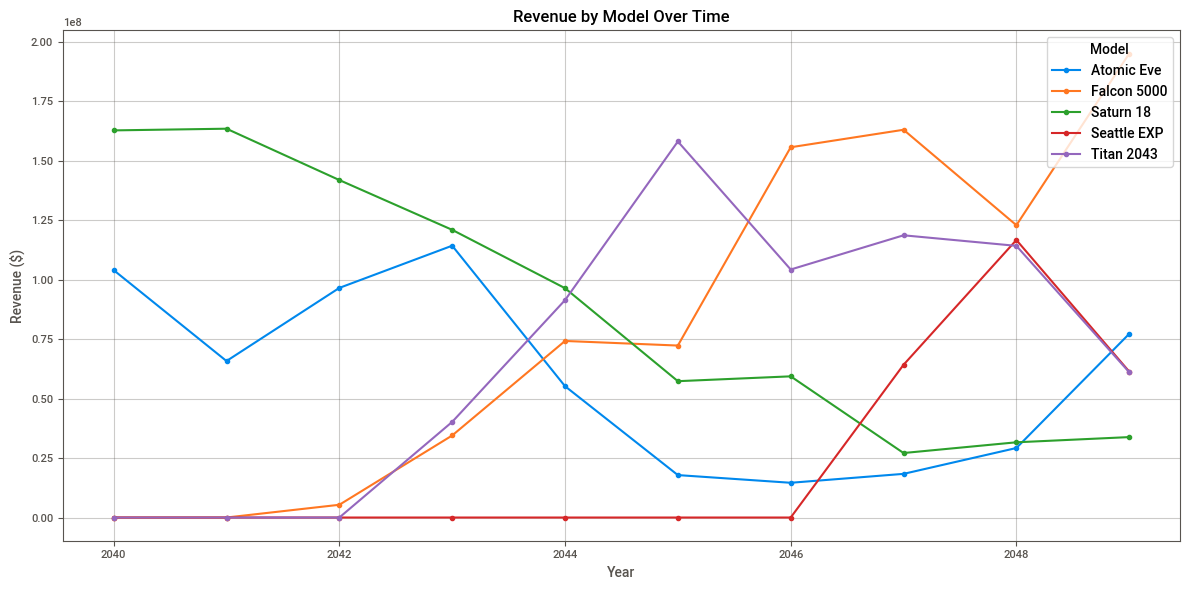

In [62]:
# Let us plot this to see the trend visually
revenue_by_model = sales.groupby(
    ['year', 'product'])['revenue']\
    .sum().unstack(fill_value=0)

revenue_by_model.plot(
    kind='line',
    figsize=(12, 6),
    marker='o')

plt.title('Revenue by Model Over Time')
plt.ylabel('Revenue ($)')
plt.xlabel('Year')
plt.legend(title='Model')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/revenue_by_model.png',
    dpi=150, bbox_inches='tight')
plt.show()

Saturn 18 declining fast
Falcon 5000 is the new revenue leader
Atomic Eve collapsed post 2044 nuclear accident
Seattle EXP growing fast since 2047 launch

In [63]:
# Units sold by model per year
# Revenue grew but what about volume?
sales.groupby(['year', 'product'])['revenue']\
    .count().unstack(fill_value=0)

product,Atomic Eve,Falcon 5000,Saturn 18,Seattle EXP,Titan 2043
year,,,,,
2040,11,0,139,0,0
2041,7,0,139,0,0
2042,10,2,129,0,0
2043,11,12,104,0,16
2044,5,25,80,0,39
2045,2,26,48,0,66
2046,2,55,51,0,43
2047,2,54,23,9,50
2048,3,46,26,16,50


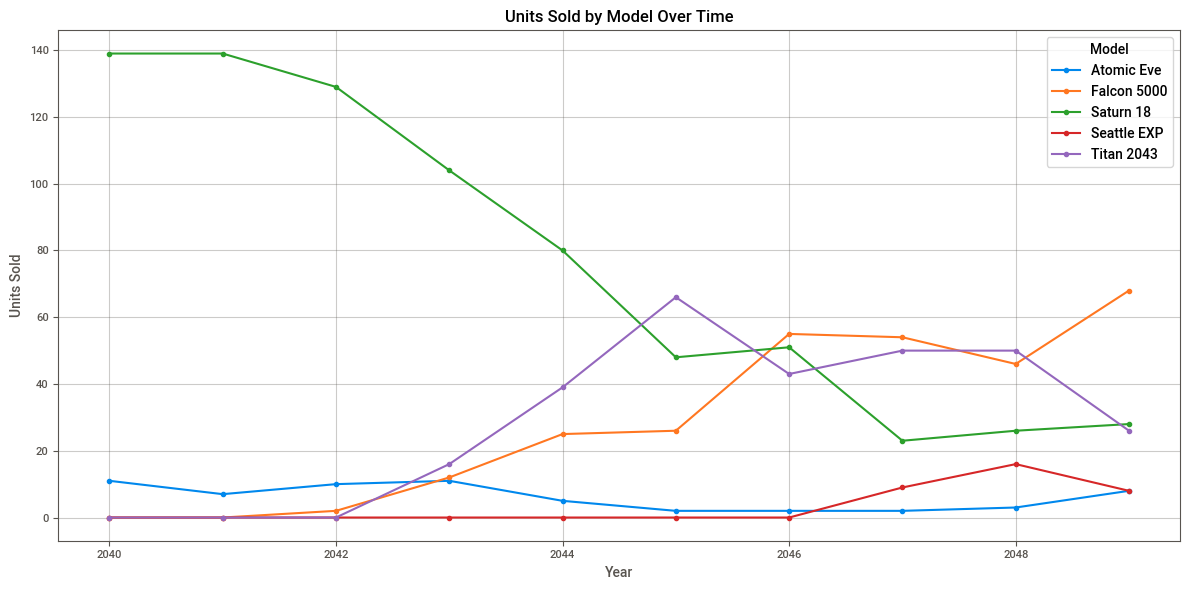

In [64]:
# Plot units sold by model over time
units_by_model = sales.groupby(
    ['year', 'product'])['revenue']\
    .count().unstack(fill_value=0)

units_by_model.plot(
    kind='line',
    figsize=(12, 6),
    marker='o')

plt.title('Units Sold by Model Over Time')
plt.ylabel('Units Sold')
plt.xlabel('Year')
plt.legend(title='Model')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/units_by_model.png',
    dpi=150, bbox_inches='tight')
plt.show()

Saturn 18 volume collapsed by 80% in 10 years
Falcon 5000 is fastest growing model
Titan 2043 peaked and now declining
Atomic Eve flatlined after nuclear accident

In [65]:
# How much commission are we paying per model?
sales.groupby('product')['commission_paid']\
    .sum().sort_values(ascending=False)

product
Saturn 18      54837845
Falcon 5000    52247299
Titan 2043     42808963
Atomic Eve     36436130
Seattle EXP    15900322
Name: commission_paid, dtype: int64

In [66]:
# What percentage of revenue goes to commission per model?
commission_rate = sales.groupby('product').agg(
    total_revenue=('revenue', 'sum'),
    total_commission=('commission_paid', 'sum')
).reset_index()

commission_rate['commission_rate_pct'] = (
    commission_rate['total_commission'] /
    commission_rate['total_revenue'] * 100
).round(2)

commission_rate.sort_values(
    'commission_rate_pct', ascending=False)

# This tells us which models are eating
# the most margin through commissions

,product,total_revenue,total_commission,commission_rate_pct
3,Seattle EXP,242102548,15900322,6.57
1,Falcon 5000,822517036,52247299,6.35
4,Titan 2043,687478365,42808963,6.23
0,Atomic Eve,592713226,36436130,6.15
2,Saturn 18,894140228,54837845,6.13


Commission rates are very similar across all models: between 6.1% and 6.6%

customer
Dick's Drive-In               946622697
Armstrong Industrial          706089837
Pagliacci Pizza               457681548
Sound Transit                 444613587
U.S. Department of Defense    389395531
Amazon                        168853159
Boeing                        125695044
Name: revenue, dtype: int64


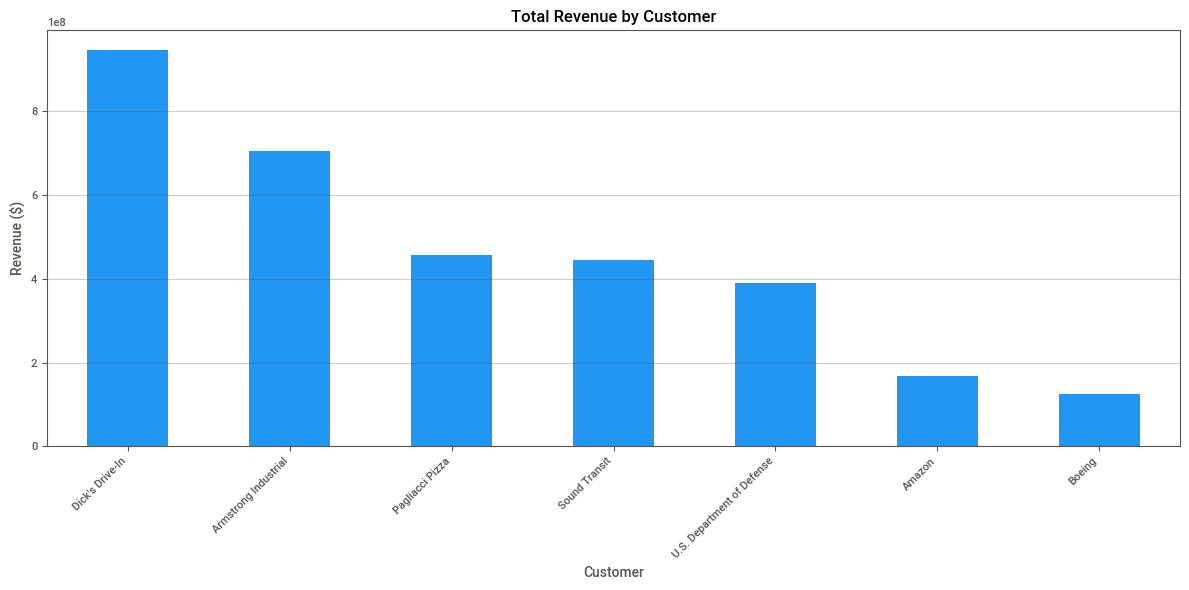

In [67]:
# Who are our biggest customers by revenue?
customer_revenue = sales.groupby('customer')['revenue']\
    .sum().sort_values(ascending=False)

print(customer_revenue)

# Plot it
customer_revenue.plot(
    kind='bar',
    figsize=(12, 6),
    color='#2196F3')

plt.title('Total Revenue by Customer')
plt.ylabel('Revenue ($)')
plt.xlabel('Customer')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('output/revenue_by_customer.png',
    dpi=150, bbox_inches='tight')
plt.show()

1. Dick's Drive-In is our biggest customer
2. Armstrong Industrial close behind at $706M
3. Amazon and Boeing at the bottom

In [68]:
# Who are our top performing salespeople?
sales.groupby('sold_by')['revenue']\
    .sum().sort_values(ascending=False)

sold_by
Leo Rockett        953262085
Chase Armstrong    752519750
Vega Zenith        389134426
Cassio Skyler      318320488
Nova Kepler        306540053
Atlas Ryder        252459518
Stella Ignis       119602071
Luna Vector         76948407
Jet Falconer        35849663
Orion Blaze         34314942
Name: revenue, dtype: int64

1. Leo Rockett is our top salesperson by far
2. Chase Armstrong close behind
3. Big drop off after the top two

In [69]:
# Is the average selling price per model going up or down?
sales.groupby(['year', 'product'])['revenue']\
    .mean().unstack(fill_value=0).round(0)

product,Atomic Eve,Falcon 5000,Saturn 18,Seattle EXP,Titan 2043
year,,,,,
2040,9449542.0,0.0,1170184.0,0.0,0.0
2041,9392854.0,0.0,1175289.0,0.0,0.0
2042,9647732.0,2677516.0,1099126.0,0.0,0.0
2043,10382937.0,2872484.0,1162197.0,0.0,2510990.0
2044,11034821.0,2967294.0,1204503.0,0.0,2342056.0
2045,8913968.0,2779064.0,1193424.0,0.0,2393853.0
2046,7299292.0,2828587.0,1163134.0,0.0,2423311.0
2047,9171977.0,3016985.0,1178290.0,7130358.0,2371566.0
2048,9735185.0,2669920.0,1215667.0,7288037.0,2282861.0


1. Atomic Eve is most expensive
2. Seattle EXP commands premium pricing ~$7M per unit
3. Saturn 18 cheapest

ANALYZING PRODUCTION LINE INVOICE DATA

model
Titan 2043     7.256088e+08
Falcon 5000    6.946361e+08
Saturn 18      6.113045e+08
Atomic Eve     5.370853e+08
Seattle EXP    2.657872e+08
Name: amount, dtype: float64


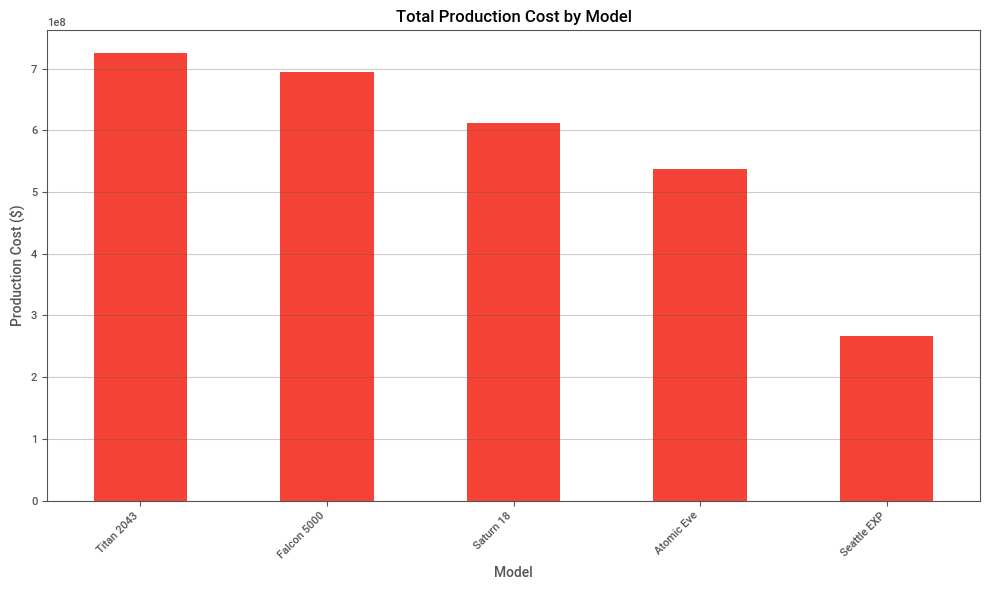

In [70]:
# Total production cost by model
prod_by_model = production.groupby('model')['amount']\
    .sum().sort_values(ascending=False)

print(prod_by_model)

prod_by_model.plot(
    kind='bar',
    figsize=(10, 6),
    color='#F44336')

plt.title('Total Production Cost by Model')
plt.ylabel('Production Cost ($)')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('output/production_cost_by_model.png',
    dpi=150, bbox_inches='tight')
plt.show()


1. Titan 2043 most expensive to produce at $725M
2. Falcon 5000 close behind at $694M
3. Atomic Eve still costing $537M despite near zero sales

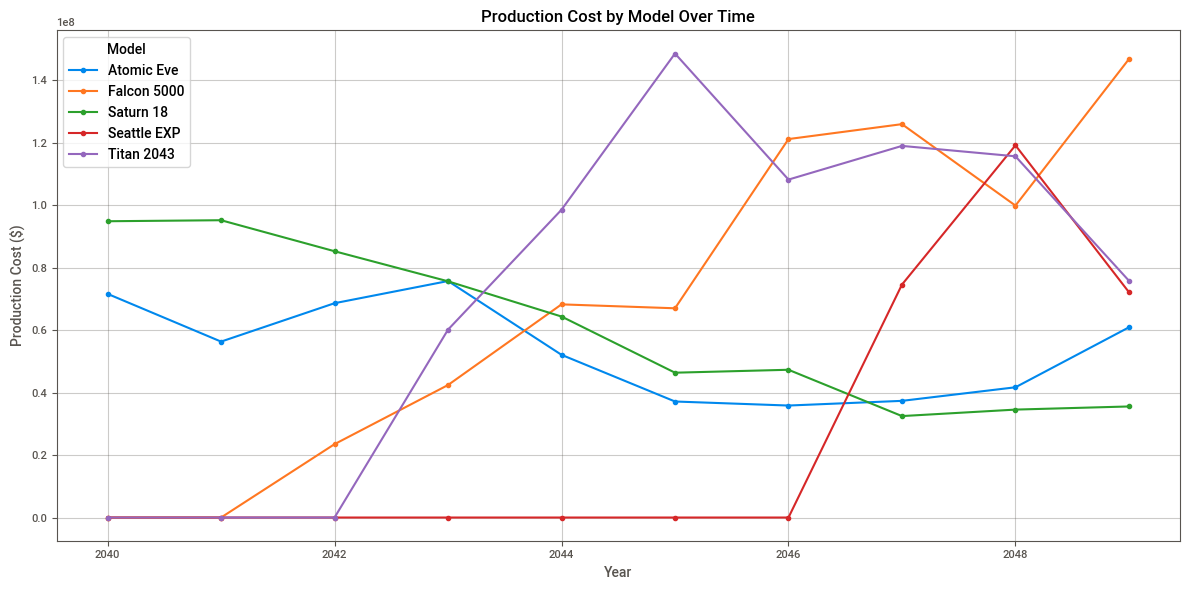

In [71]:
# How is production cost trending year over year per model?
prod_by_year = production.groupby(
    ['year', 'model'])['amount']\
    .sum().unstack(fill_value=0)

prod_by_year.plot(
    kind='line',
    figsize=(12, 6),
    marker='o')

plt.title('Production Cost by Model Over Time')
plt.ylabel('Production Cost ($)')
plt.xlabel('Year')
plt.legend(title='Model')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/production_cost_trend.png',
    dpi=150, bbox_inches='tight')
plt.show()

1. Saturn 18 production costs declining
2. Falcon 5000 costs rising sharply
3. Titan 2043 peaked in 2045 then declining
4.  Atomic Eve costs still significant despite almost no sales
5. Seattle EXP rising from 2047: new model ramping up

    year      product  units_sold  total_revenue  total_production_cost  total_commission  gross_profit  margin_pct
0   2040   Atomic Eve          11      103944966           7.157799e+07           6668225   25698755.00       24.72
1   2040    Saturn 18         139      162655574           9.482156e+07           9986546   57847464.01       35.56
2   2041   Atomic Eve           7       65749978           5.629999e+07           3963708    5486279.00        8.34
3   2041    Saturn 18         139      163365233           9.514801e+07           9920029   58297197.00       35.69
4   2042   Atomic Eve          10       96477315           6.859093e+07           5892291   21994098.00       22.80
5   2042  Falcon 5000           2        5355031           2.348077e+07            351082  -18476821.00     -345.04
6   2042    Saturn 18         129      141787221           8.522212e+07           9433871   47131228.00       33.24
7   2043   Atomic Eve          11      114212308           7.568492e+07 

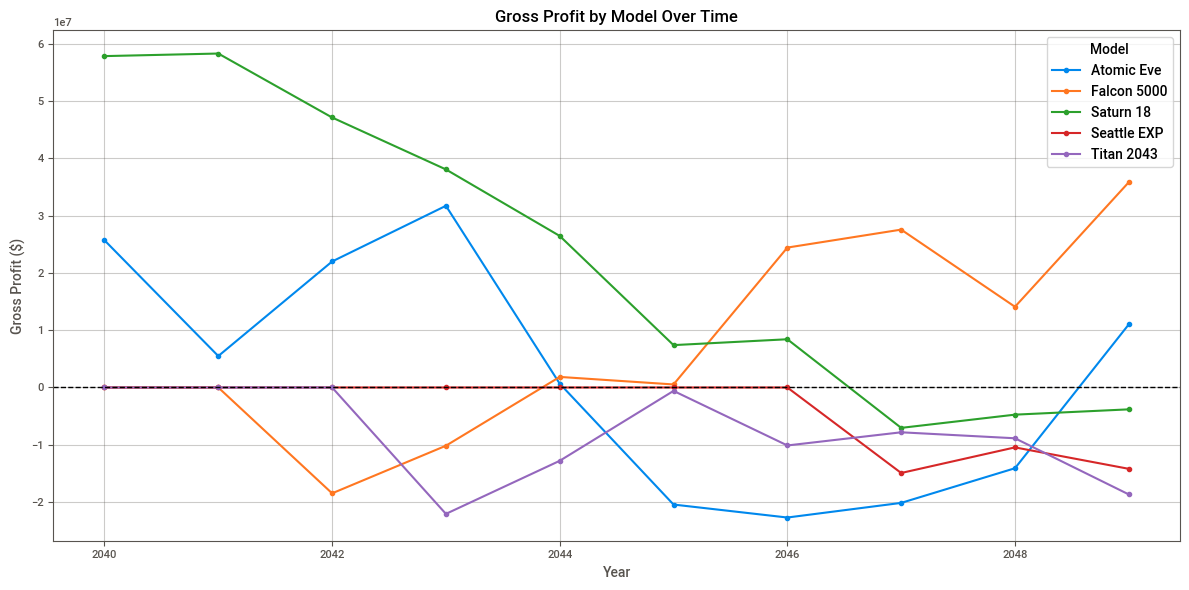

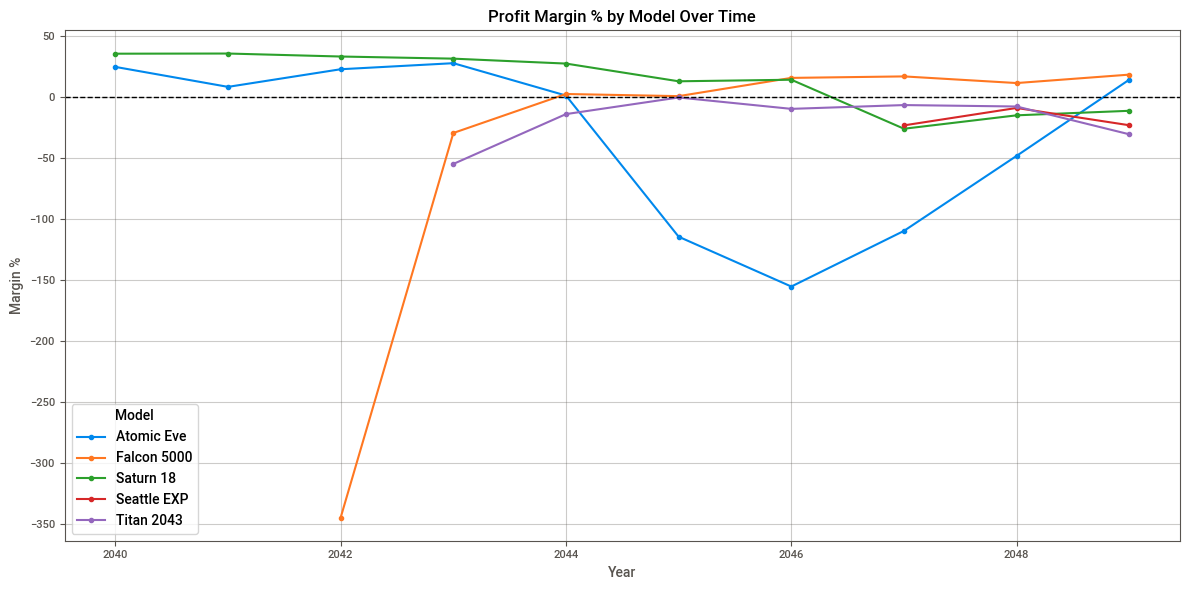

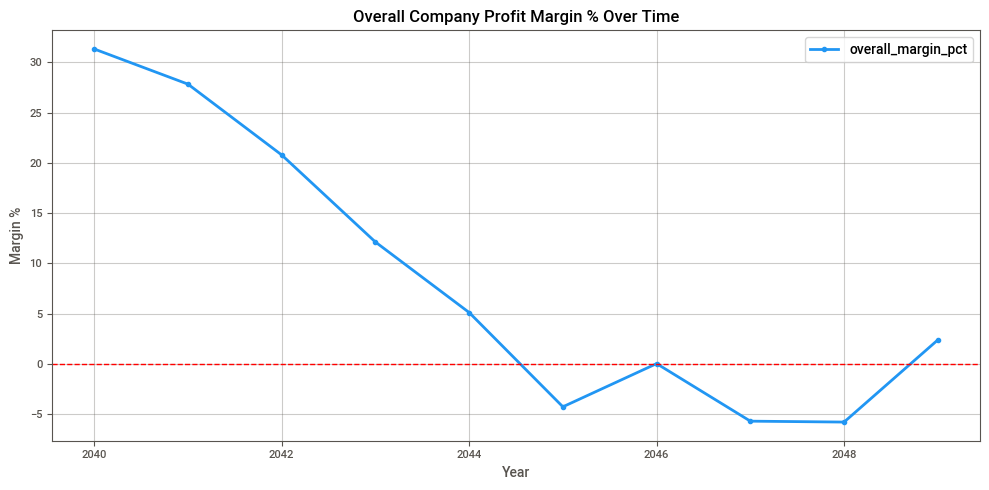

   year  overall_margin_pct
0  2040               31.34
1  2041               27.84
2  2042               20.79
3  2043               12.12
4  2044                5.10
5  2045               -4.29
6  2046                0.01
7  2047               -5.72
8  2048               -5.81
9  2049                2.37


In [72]:
# Combine revenue and production costs to calculate gross profit
revenue = sales.groupby(['year', 'product']).agg(
    units_sold=('revenue', 'count'),
    total_revenue=('revenue', 'sum'),
    total_commission=('commission_paid', 'sum')
).reset_index()

prod_cost = production.groupby(
    ['year', 'model'])['amount']\
    .sum().reset_index()
prod_cost.columns = ['year', 'product', 'total_production_cost']

profitability = revenue.merge(
    prod_cost, on=['year', 'product'], how='left')

profitability['gross_profit'] = (
    profitability['total_revenue']
    - profitability['total_commission']
    - profitability['total_production_cost'])

profitability['margin_pct'] = (
    profitability['gross_profit']
    / profitability['total_revenue'] * 100
).round(2)

print(profitability[[
    'year', 'product', 'units_sold',
    'total_revenue', 'total_production_cost',
    'total_commission', 'gross_profit',
    'margin_pct']].to_string())

# Chart 1 — Gross profit by model over time
profit_trend = profitability.groupby(
    ['year', 'product'])['gross_profit']\
    .sum().unstack(fill_value=0)

profit_trend.plot(
    kind='line',
    figsize=(12, 6),
    marker='o')

plt.title('Gross Profit by Model Over Time')
plt.ylabel('Gross Profit ($)')
plt.xlabel('Year')
plt.axhline(y=0, color='black',
    linewidth=1, linestyle='--')
plt.legend(title='Model')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/gross_profit_trend.png',
    dpi=150, bbox_inches='tight')
plt.show()

# Chart 2 — Margin % by model over time
margin_trend = profitability.pivot(
    index='year',
    columns='product',
    values='margin_pct')

margin_trend.plot(
    kind='line',
    figsize=(12, 6),
    marker='o')

plt.title('Profit Margin % by Model Over Time')
plt.ylabel('Margin %')
plt.xlabel('Year')
plt.axhline(y=0, color='black',
    linewidth=1, linestyle='--')
plt.legend(title='Model')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/margin_trend.png',
    dpi=150, bbox_inches='tight')
plt.show()

# Chart 3 — Overall company margin trend
company_margin = profitability.groupby('year').agg(
    total_revenue=('total_revenue', 'sum'),
    total_profit=('gross_profit', 'sum')
).reset_index()

company_margin['overall_margin_pct'] = (
    company_margin['total_profit'] /
    company_margin['total_revenue'] * 100
).round(2)

company_margin.plot(
    x='year',
    y='overall_margin_pct',
    kind='line',
    figsize=(10, 5),
    marker='o',
    color='#2196F3',
    linewidth=2)

plt.title('Overall Company Profit Margin % Over Time')
plt.ylabel('Margin %')
plt.xlabel('Year')
plt.axhline(y=0, color='red',
    linewidth=1, linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/overall_margin.png',
    dpi=150, bbox_inches='tight')
plt.show()

print(company_margin[['year', 'overall_margin_pct']])

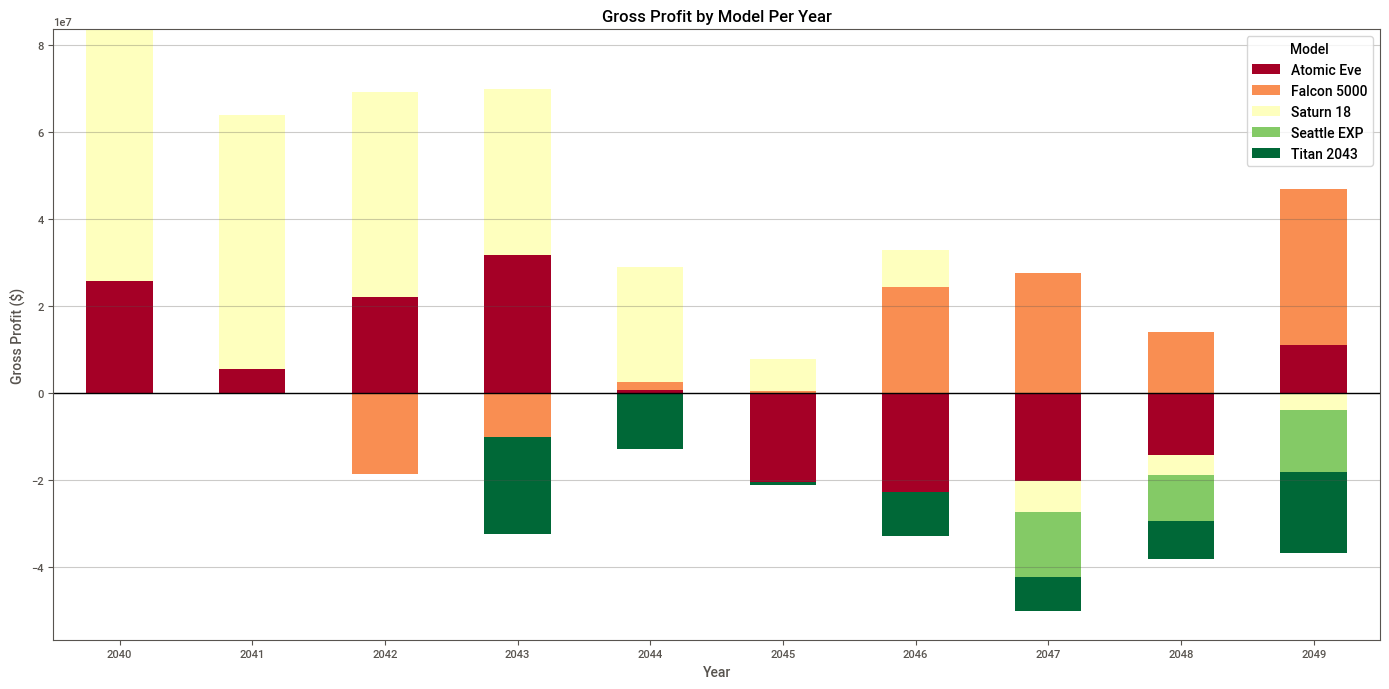

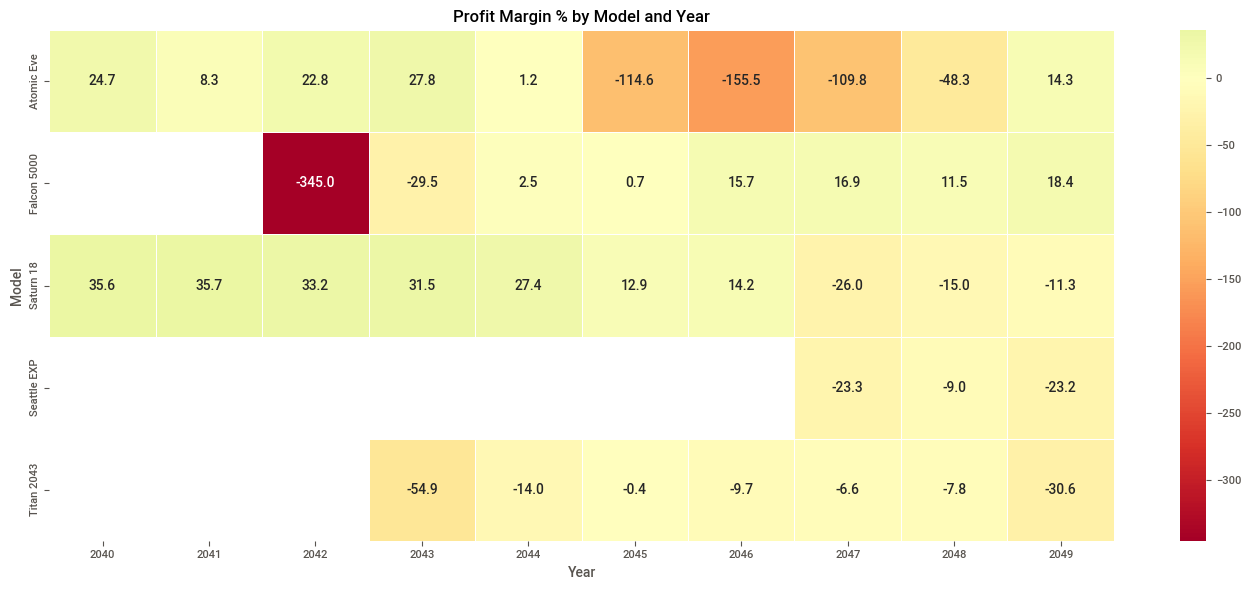

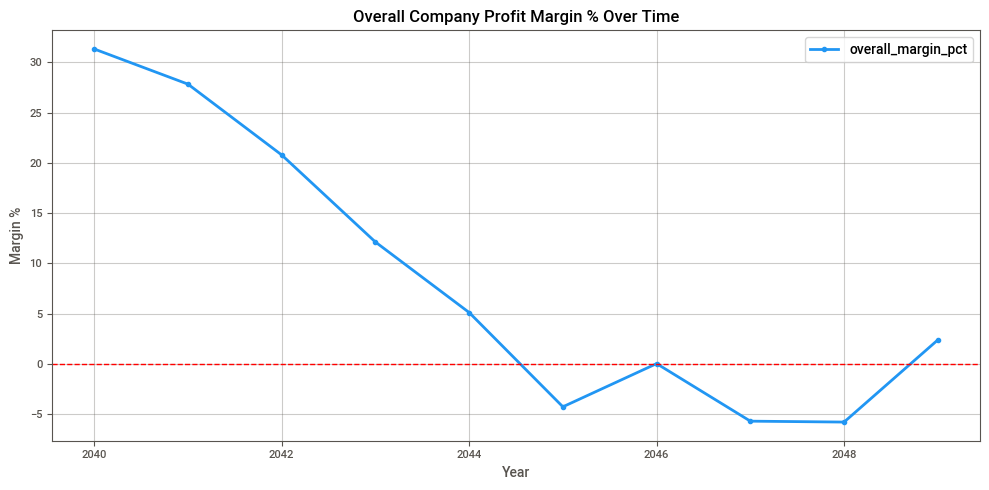

   year  overall_margin_pct
0  2040               31.34
1  2041               27.84
2  2042               20.79
3  2043               12.12
4  2044                5.10
5  2045               -4.29
6  2046                0.01
7  2047               -5.72
8  2048               -5.81
9  2049                2.37


In [73]:
# Chart 1 — Stacked bar: gross profit by model per year
profit_by_year_model = profitability.pivot(
    index='year',
    columns='product',
    values='gross_profit')

profit_by_year_model.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    colormap='RdYlGn')

plt.title('Gross Profit by Model Per Year')
plt.ylabel('Gross Profit ($)')
plt.xlabel('Year')
plt.axhline(y=0, color='black', linewidth=1)
plt.legend(title='Model', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('output/gross_profit_stacked.png',
    dpi=150, bbox_inches='tight')
plt.show()

# Chart 2 — Heatmap: margin % by model and year
import seaborn as sns

margin_pivot = profitability.pivot(
    index='product',
    columns='year',
    values='margin_pct')

plt.figure(figsize=(14, 6))
sns.heatmap(
    margin_pivot,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5)

plt.title('Profit Margin % by Model and Year')
plt.ylabel('Model')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('output/margin_heatmap.png',
    dpi=150, bbox_inches='tight')
plt.show()

# Chart 3 — Overall company margin trend
company_margin = profitability.groupby('year').agg(
    total_revenue=('total_revenue', 'sum'),
    total_profit=('gross_profit', 'sum')
).reset_index()

company_margin['overall_margin_pct'] = (
    company_margin['total_profit'] /
    company_margin['total_revenue'] * 100
).round(2)

company_margin.plot(
    x='year',
    y='overall_margin_pct',
    kind='line',
    figsize=(10, 5),
    marker='o',
    color='#2196F3',
    linewidth=2)

plt.title('Overall Company Profit Margin % Over Time')
plt.ylabel('Margin %')
plt.xlabel('Year')
plt.axhline(y=0, color='red',
    linewidth=1, linestyle='--')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/overall_margin.png',
    dpi=150, bbox_inches='tight')
plt.show()

print(company_margin[['year', 'overall_margin_pct']])

GROSS PROFIT BY MODEL YEAR
1. 2040 to 2043: company was profitable
2. Saturn 18 was the profit engine
3. Negative bars growing from 2043 onwards
4. Titan 2043 and Falcon 5000 dragging profit down
5. 2047 worst year: most negative bars
6. 2049 slight recovery: Falcon 5000 turning positive

OVERALL MARGIN
1. 31% margin in 2040: healthy company
2. Steady decline every year
3. Crossed zero in 2045: loss making
4. Bottomed out 2047-2048
5. Slight recovery 2049: Falcon 5000 helping

ENERGY PRICES ANALYSIS

      avg_liquid_hydrogen  avg_apcp  avg_uranium
year                                            
2040               162.24    119.86      1021.27
2041               151.33    118.97      1011.12
2042               129.88    128.98      1200.37
2043               119.72    134.86      1155.21
2044               107.85    138.84       940.20
2045                95.95    145.81       314.96
2046               149.90    162.70       151.00
2047                88.00    164.12       302.17
2048                79.99    187.98       700.87
2049               200.78    162.89       740.89


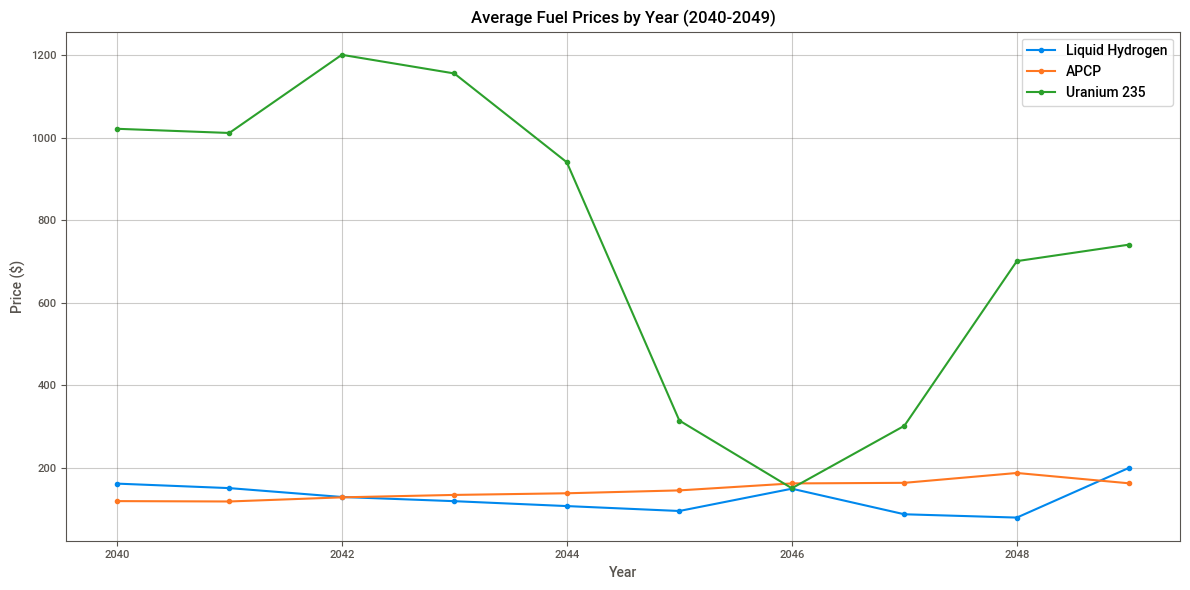

In [74]:
# How have fuel prices changed over time?
# Only historical data — 2040 to 2049
energy_hist = energy[energy['year'] <= 2049]

fuel_trend = energy_hist.groupby('year').agg(
    avg_liquid_hydrogen=('liquid_hydrogen_price', 'mean'),
    avg_apcp=('apcp_price', 'mean'),
    avg_uranium=('uranium_235_price', 'mean')
).round(2)

print(fuel_trend)

fuel_trend.plot(
    kind='line',
    figsize=(12, 6),
    marker='o')

plt.title('Average Fuel Prices by Year (2040-2049)')
plt.ylabel('Price ($)')
plt.xlabel('Year')
plt.legend(['Liquid Hydrogen', 'APCP', 'Uranium 235'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/fuel_prices.png',
    dpi=150, bbox_inches='tight')
plt.show()

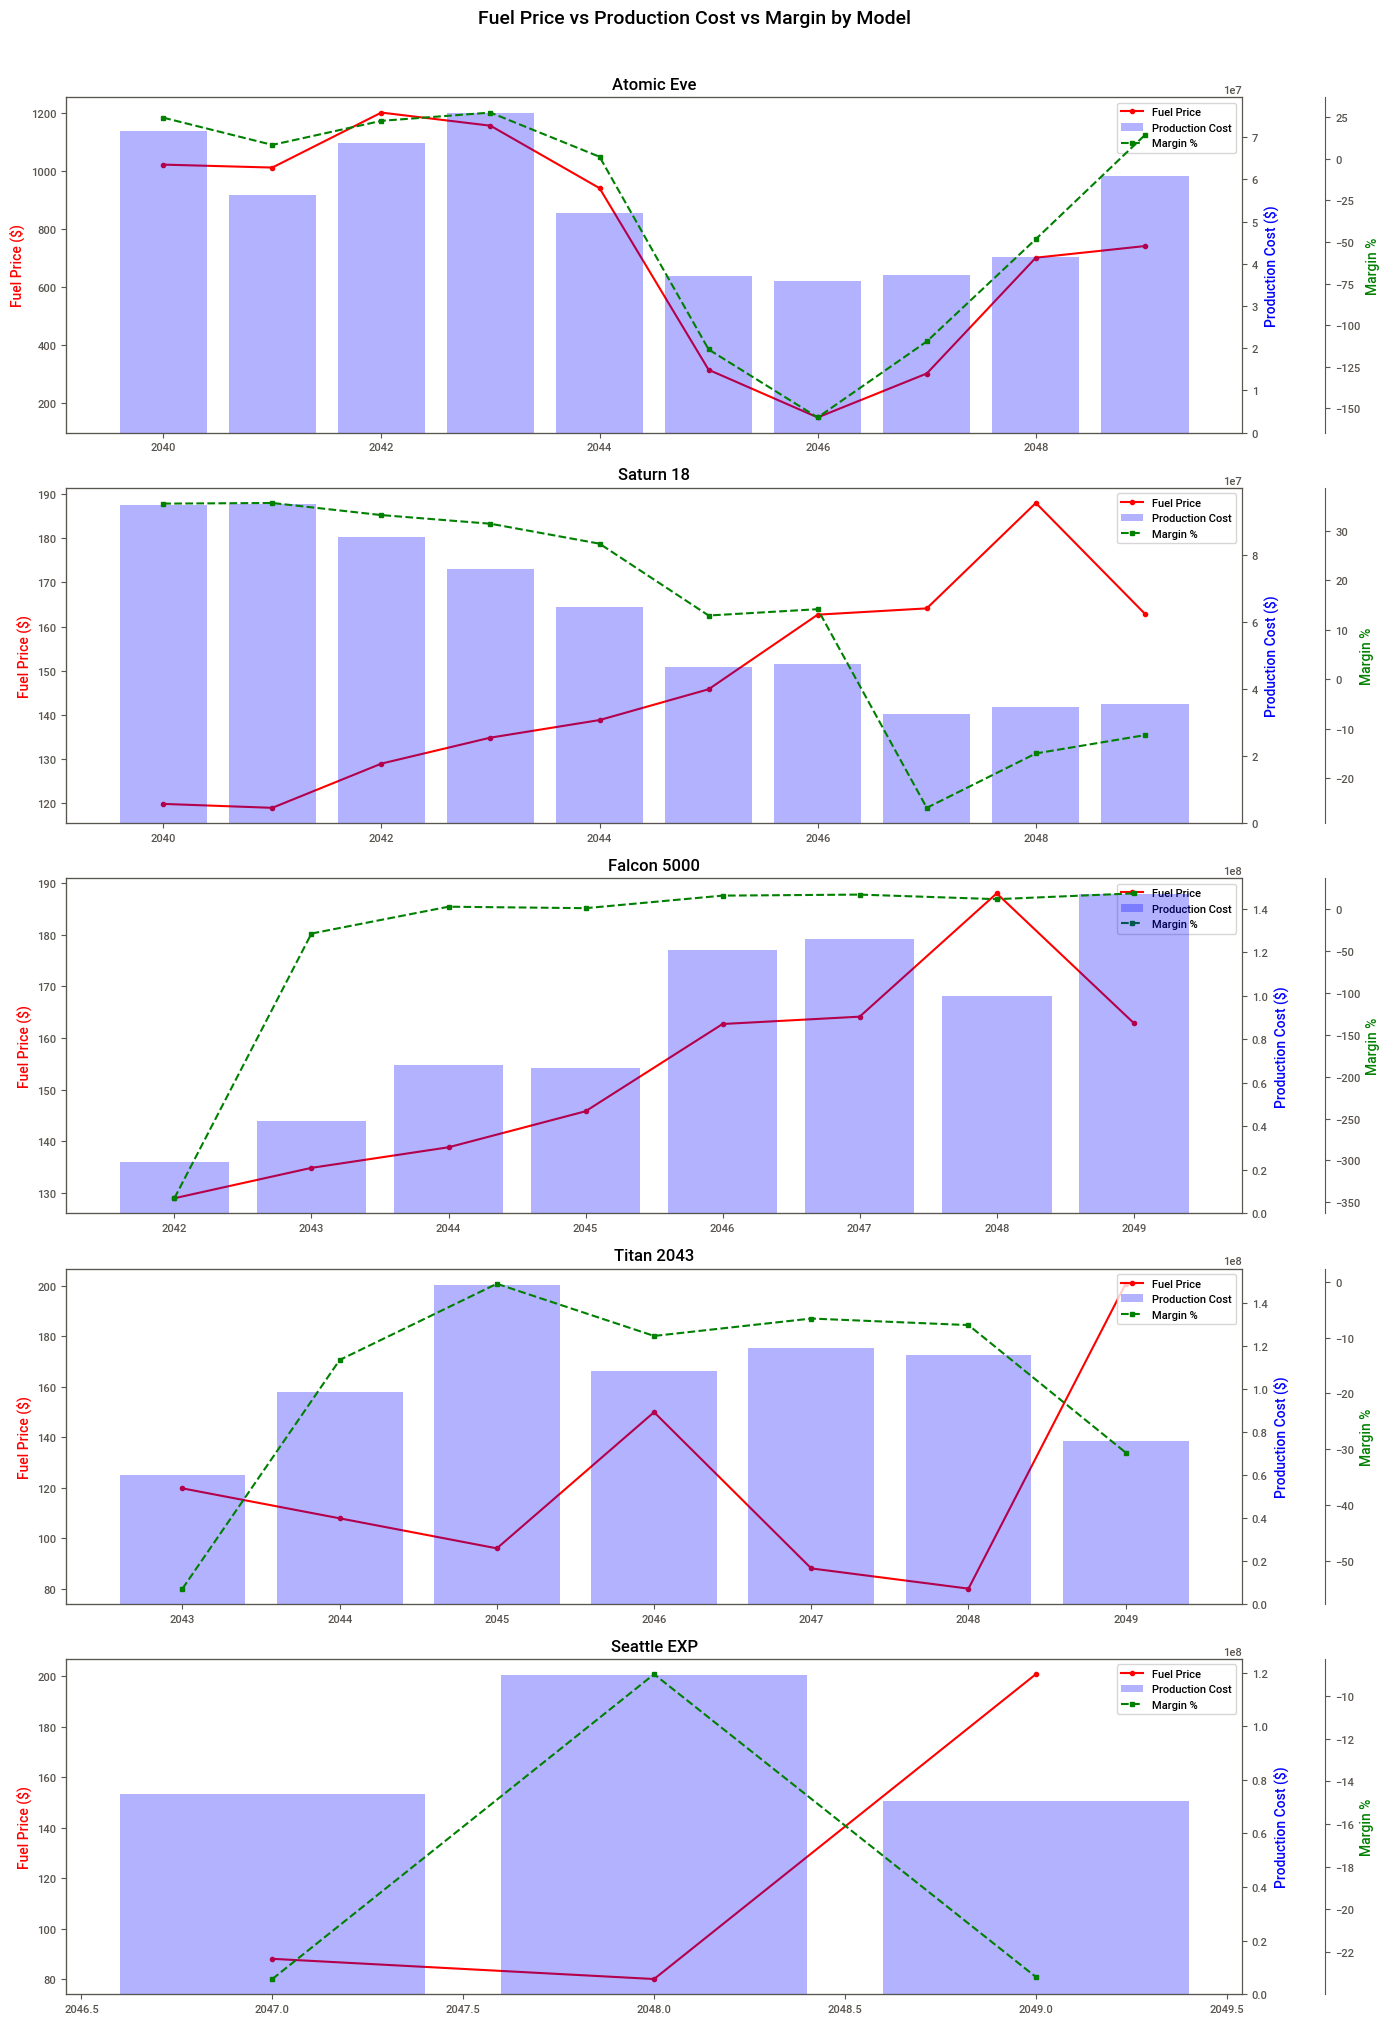

In [75]:
# Map fuel type to each model
fuel_map = {
    'Atomic Eve': 'avg_uranium',
    'Titan 2043': 'avg_liquid_hydrogen',
    'Seattle EXP': 'avg_liquid_hydrogen',
    'Saturn 18': 'avg_apcp',
    'Falcon 5000': 'avg_apcp'
}

# Get fuel prices per year
fuel_by_year = energy_hist.groupby('year').agg(
    avg_liquid_hydrogen=('liquid_hydrogen_price', 'mean'),
    avg_apcp=('apcp_price', 'mean'),
    avg_uranium=('uranium_235_price', 'mean')
).round(2).reset_index()

# Add fuel price to profitability table
profitability['fuel_col'] = profitability[
    'product'].map(fuel_map)

profitability_fuel = profitability.merge(
    fuel_by_year, on='year', how='left')

# Get the relevant fuel price for each model
profitability_fuel['fuel_price'] = profitability_fuel\
    .apply(lambda row: row[row['fuel_col']]
    if pd.notna(row['fuel_col']) else None, axis=1)

# Now plot fuel price vs production cost vs margin
# for each model separately
fig, axes = plt.subplots(
    5, 1, figsize=(14, 20))

models = profitability_fuel['product'].unique()

for i, model in enumerate(models):
    df = profitability_fuel[
        profitability_fuel['product'] == model]

    ax1 = axes[i]
    ax2 = ax1.twinx()
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(
        ('outward', 60))

    ax1.plot(df['year'],
        df['fuel_price'],
        color='red', marker='o',
        label='Fuel Price')
    ax2.bar(df['year'],
        df['total_production_cost'],
        alpha=0.3, color='blue',
        label='Production Cost')
    ax3.plot(df['year'],
        df['margin_pct'],
        color='green', marker='s',
        linestyle='--',
        label='Margin %')

    ax1.set_title(f'{model}')
    ax1.set_ylabel('Fuel Price ($)', color='red')
    ax2.set_ylabel('Production Cost ($)', color='blue')
    ax3.set_ylabel('Margin %', color='green')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3,
        labels1 + labels2 + labels3,
        loc='upper right', fontsize=8)

plt.suptitle(
    'Fuel Price vs Production Cost vs Margin by Model',
    fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/fuel_vs_cost_vs_margin.png',
    dpi=150, bbox_inches='tight')
plt.show()

Titan 2043: cheap fuel, lower costs
but still losing money
Price point is simply too low

Seattle EXP: expensive fuel, high costs
but margins improving
Because it sells for $7M per rocket
Price point saves it

Atomic EvE: Fuel price crashed
Production cost stayed high
Margin went deeply negative
Sales died but costs did not follow

Saturn 18: Fuel price slowly rising
Production cost declining
But margin still going negative
Revenue per unit just too low
Cannot keep up even as we make fewer

Falcon 5000:
Fuel price slowly rising
Production cost rising too
but margin improving
because selling price is strong enough
Volume is helping spread the costs

In [76]:
# Bring everything together
# Revenue, commission, production cost, specs per model

# Revenue and commission per model
rev = sales.groupby('product').agg(
    units_sold=('revenue', 'count'),
    total_revenue=('revenue', 'sum'),
    avg_price=('revenue', 'mean'),
    total_commission=('commission_paid', 'sum'),
    avg_payload=('payload_(metric_tones)', 'mean'),
    avg_fuel_consumption=('fuel_consumption_(in_metric_tonnes)', 'mean'),
    avg_lifetime=('est._lifetime_(#_launches)', 'mean')
).round(2).reset_index()

# Production cost per model
prod = production.groupby('model')['amount']\
    .sum().reset_index()
prod.columns = ['product', 'total_production_cost']

# Merge
full_picture = rev.merge(prod, on='product', how='left')

# Gross profit
full_picture['gross_profit'] = (
    full_picture['total_revenue']
    - full_picture['total_commission']
    - full_picture['total_production_cost']
)

full_picture['margin_pct'] = (
    full_picture['gross_profit']
    / full_picture['total_revenue'] * 100
).round(2)

# Cost per unit
full_picture['production_cost_per_unit'] = (
    full_picture['total_production_cost']
    / full_picture['units_sold']
).round(2)

full_picture['profit_per_unit'] = (
    full_picture['gross_profit']
    / full_picture['units_sold']
).round(2)

print(full_picture[[
    'product',
    'units_sold',
    'avg_price',
    'production_cost_per_unit',
    'profit_per_unit',
    'margin_pct',
    'avg_payload',
    'avg_fuel_consumption',
    'avg_lifetime'
]].to_string())

       product  units_sold   avg_price  production_cost_per_unit  profit_per_unit  margin_pct  avg_payload  avg_fuel_consumption  avg_lifetime
0   Atomic Eve          61  9716610.26                8804676.89        314619.77        3.24       2000.0                   1.0          20.0
1  Falcon 5000         288  2855961.93                2411930.82        262616.88        9.20        350.0                1250.0          15.0
2    Saturn 18         767  1165763.01                 797007.18        297259.29       25.50        300.0                1000.0          12.0
3  Seattle EXP          33  7336440.85                8054156.58      -1199543.67      -16.35        350.0                 750.0          12.0
4   Titan 2043         290  2370615.05                2502099.22       -279101.28      -11.77        600.0                1250.0          20.0


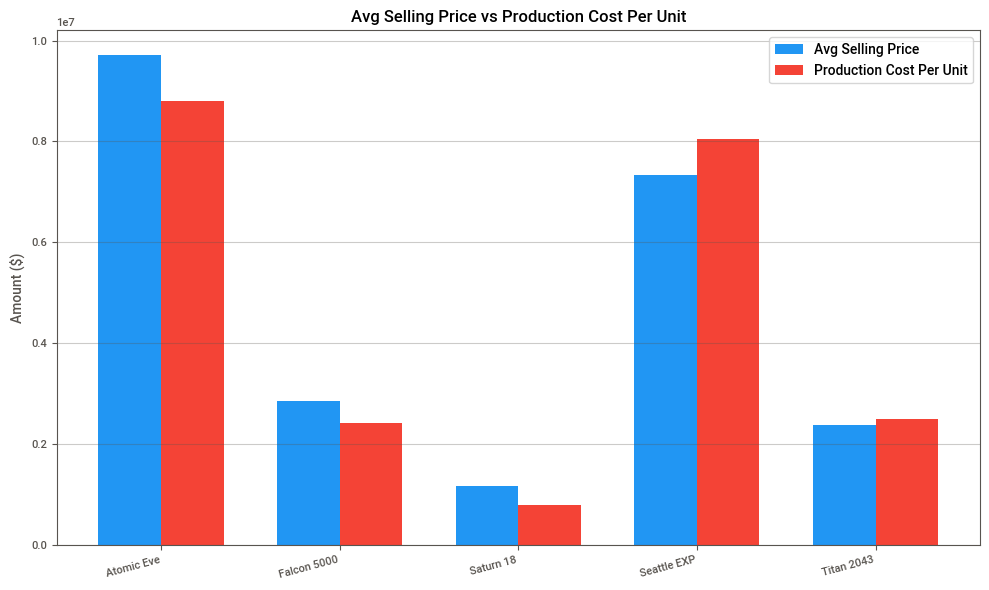

In [77]:
# Plot avg price vs production cost per unit
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(full_picture))
width = 0.35

ax.bar([i - width/2 for i in x],
    full_picture['avg_price'],
    width, label='Avg Selling Price',
    color='#2196F3')
ax.bar([i + width/2 for i in x],
    full_picture['production_cost_per_unit'],
    width, label='Production Cost Per Unit',
    color='#F44336')

ax.set_xticks(list(x))
ax.set_xticklabels(full_picture['product'],
    rotation=15, ha='right')
ax.set_ylabel('Amount ($)')
ax.set_title('Avg Selling Price vs Production Cost Per Unit')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('output/price_vs_cost_per_unit.png',
    dpi=150, bbox_inches='tight')
plt.show()



1. Saturn 18 biggest gap between price and cost:most profitable per unit
2. Seattle EXP cost exceeds price: losing money per unit right now
3. Titan 2043 cost slightly above price: never been profitable
4. Falcon 5000 gap growing
5. Atomic Eve tiny gap: high price but high cost too

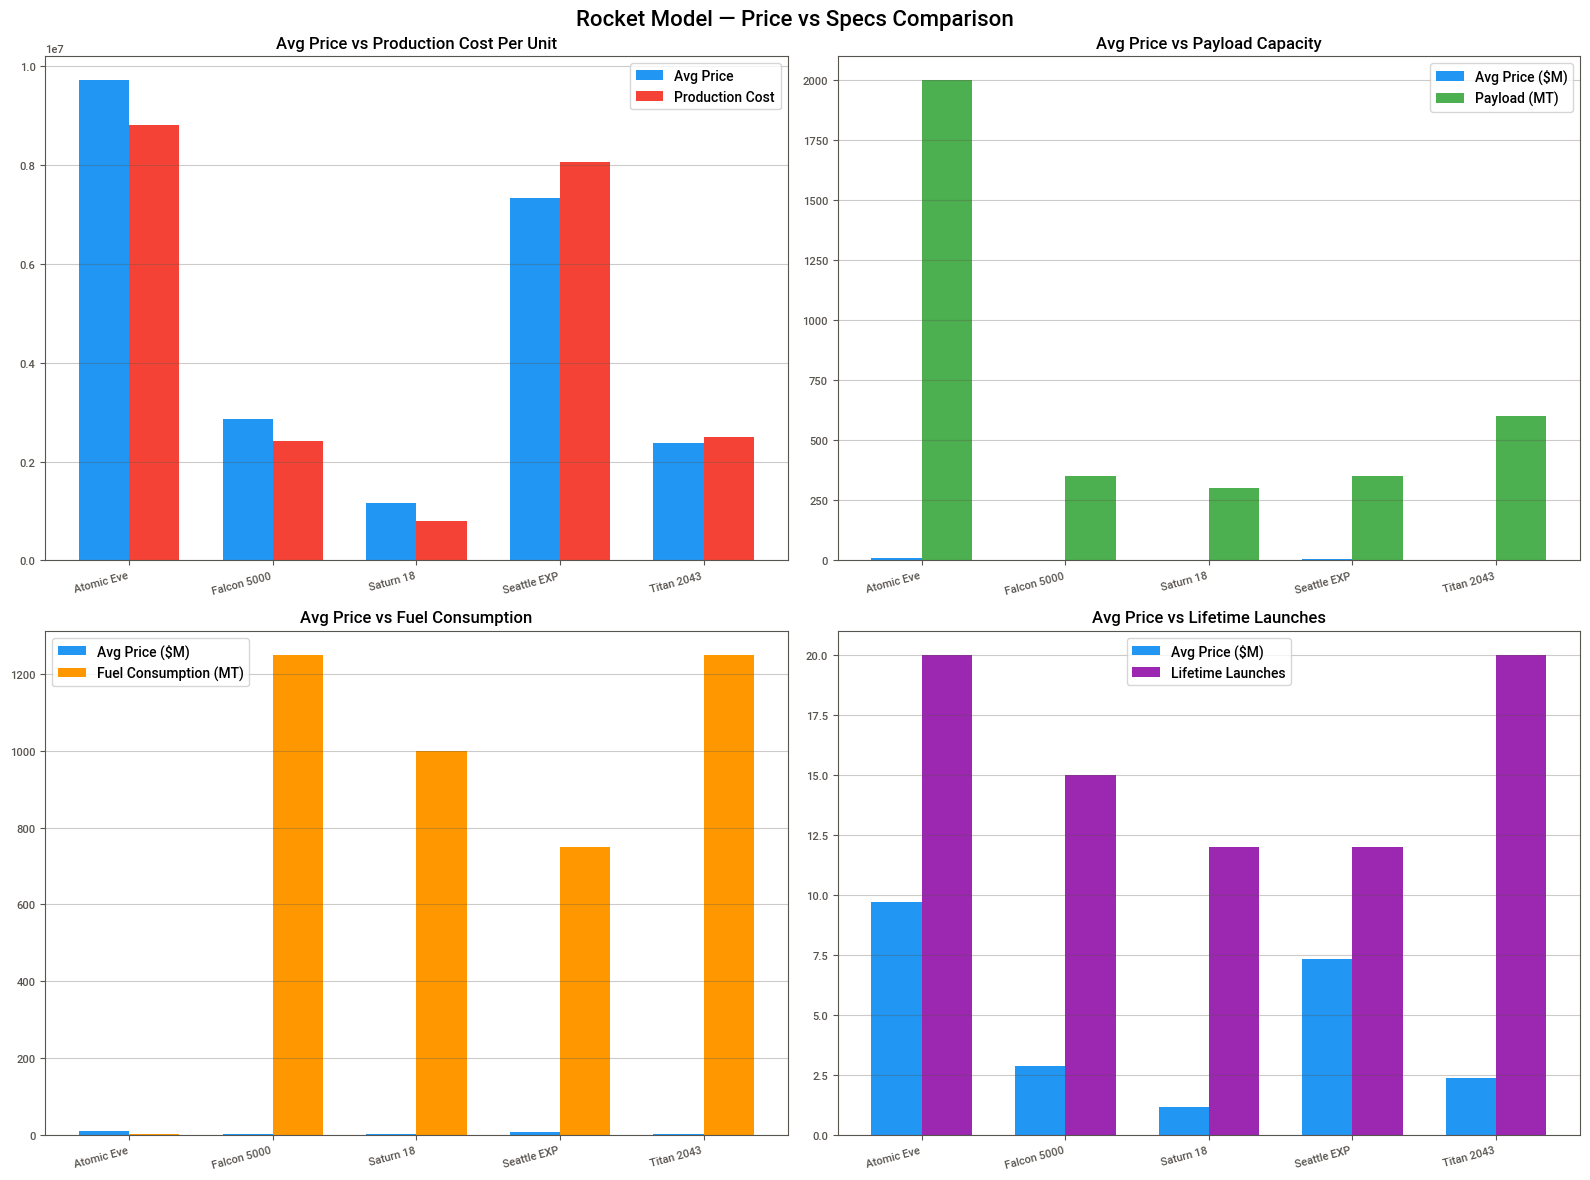

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = full_picture['product']
x = range(len(models))
width = 0.35

# Chart 1 — Price vs Production Cost
ax1 = axes[0, 0]
ax1.bar([i - width/2 for i in x],
    full_picture['avg_price'],
    width, label='Avg Price', color='#2196F3')
ax1.bar([i + width/2 for i in x],
    full_picture['production_cost_per_unit'],
    width, label='Production Cost', color='#F44336')
ax1.set_title('Avg Price vs Production Cost Per Unit')
ax1.set_xticks(list(x))
ax1.set_xticklabels(models, rotation=15, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Chart 2 — Price vs Payload
ax2 = axes[0, 1]
ax2.bar([i - width/2 for i in x],
    full_picture['avg_price'] / 1e6,
    width, label='Avg Price ($M)', color='#2196F3')
ax2.bar([i + width/2 for i in x],
    full_picture['avg_payload'],
    width, label='Payload (MT)', color='#4CAF50')
ax2.set_title('Avg Price vs Payload Capacity')
ax2.set_xticks(list(x))
ax2.set_xticklabels(models, rotation=15, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Chart 3 — Price vs Fuel Consumption
ax3 = axes[1, 0]
ax3.bar([i - width/2 for i in x],
    full_picture['avg_price'] / 1e6,
    width, label='Avg Price ($M)', color='#2196F3')
ax3.bar([i + width/2 for i in x],
    full_picture['avg_fuel_consumption'],
    width, label='Fuel Consumption (MT)',
    color='#FF9800')
ax3.set_title('Avg Price vs Fuel Consumption')
ax3.set_xticks(list(x))
ax3.set_xticklabels(models, rotation=15, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Chart 4 — Price vs Lifetime Launches
ax4 = axes[1, 1]
ax4.bar([i - width/2 for i in x],
    full_picture['avg_price'] / 1e6,
    width, label='Avg Price ($M)', color='#2196F3')
ax4.bar([i + width/2 for i in x],
    full_picture['avg_lifetime'],
    width, label='Lifetime Launches', color='#9C27B0')
ax4.set_title('Avg Price vs Lifetime Launches')
ax4.set_xticks(list(x))
ax4.set_xticklabels(models, rotation=15, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Rocket Model — Price vs Specs Comparison',
    fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('output/price_vs_specs.png',
    dpi=150, bbox_inches='tight')
plt.show()

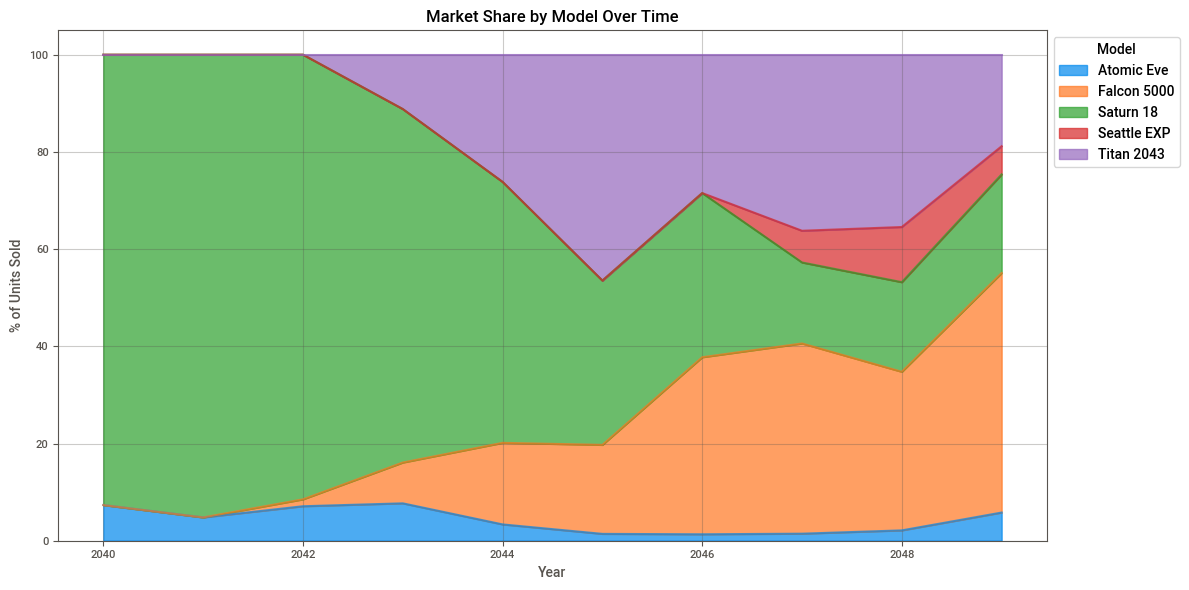

In [79]:
# Market share shift over time
units_by_year = sales.groupby(
    ['year', 'product'])['revenue']\
    .count().unstack(fill_value=0)

market_share = units_by_year.div(
    units_by_year.sum(axis=1), axis=0) * 100

market_share.plot(
    kind='area',
    figsize=(12, 6),
    stacked=True,
    alpha=0.7)

plt.title('Market Share by Model Over Time')
plt.ylabel('% of Units Sold')
plt.xlabel('Year')
plt.legend(title='Model',
    bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/market_share.png',
    dpi=150, bbox_inches='tight')
plt.show()

# 2040: Saturn 18 owned 93% of all sales
# Falcon 5000 and Titan 2043 did not exist yet
# 2043: Falcon 5000 and Titan 2043 enter market
# Saturn 18 starts losi

2040-2042: 
Saturn 18 dominated: 25% margin
Company was profitable

2043-2045:
Titan 2043 grew to dominate
Never profitable
This killed overall margins

2046-2048:
Falcon 5000 growing but Titan 2043 still too large
Both needed to improve margins

2049:
Falcon 5000 at 49% — 18% margin
Finally pulling margins up but Titan 2043 still dragging

In [80]:
# Recreate profitability dataframe
revenue = sales.groupby(
    ['year', 'product']
).agg(
    units_sold=('revenue', 'count'),
    total_revenue=('revenue', 'sum'),
    total_commission=('commission_paid', 'sum')
).reset_index()

prod_cost = production.groupby(
    ['year', 'model']
).agg(
    total_production_cost=('amount', 'sum')
).reset_index()
prod_cost.columns = [
    'year', 'product', 'total_production_cost']

profitability = revenue.merge(
    prod_cost, on=['year', 'product'], how='left')

profitability['gross_profit'] = (
    profitability['total_revenue']
    - profitability['total_commission']
    - profitability['total_production_cost'])

profitability['margin_pct'] = (
    profitability['gross_profit']
    / profitability['total_revenue'] * 100
).round(2)

print("✅ Profitability recreated")
print(profitability.shape)

✅ Profitability recreated
(38, 8)


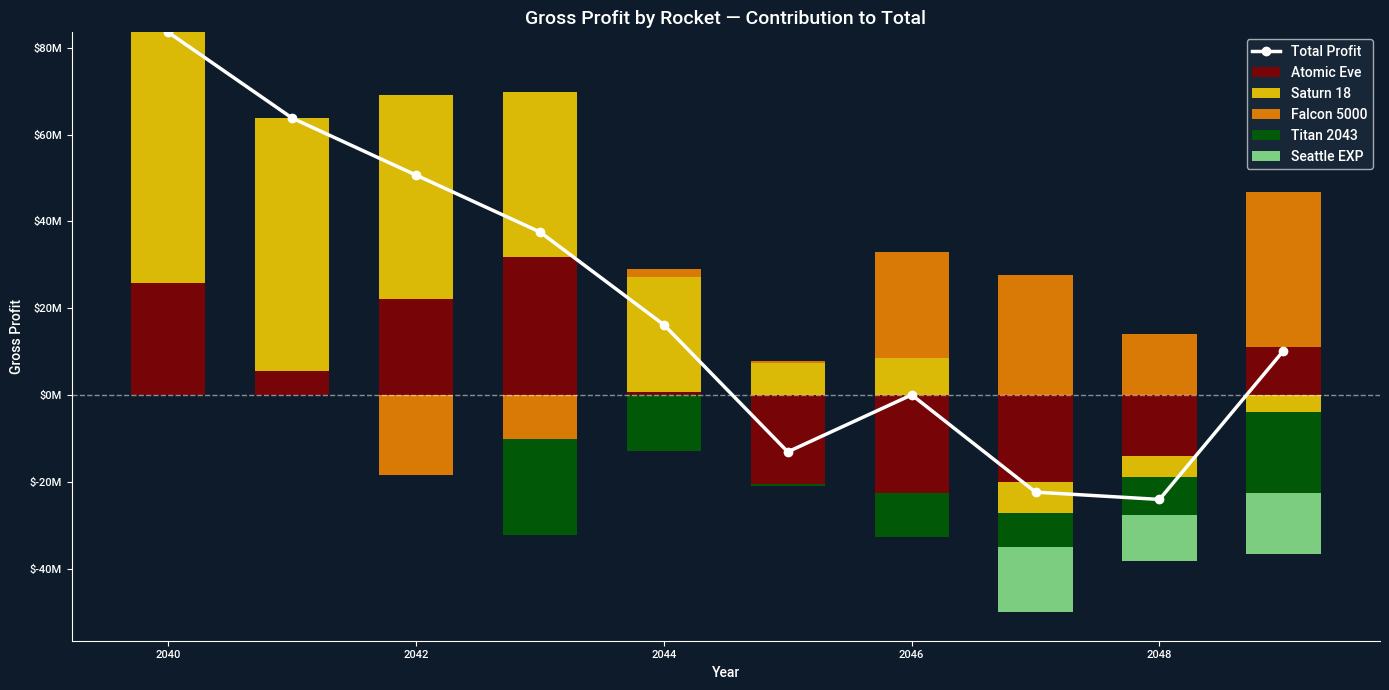

In [81]:
# Cleaner version — add total profit line
fig, ax = plt.subplots(figsize=(14, 7))

models = profitability['product'].unique()
years = sorted(profitability['year'].unique())

colors = {
    'Atomic Eve': '#8B0000',
    'Falcon 5000': '#FF8C00',
    'Saturn 18': '#FFD700',
    'Seattle EXP': '#90EE90',
    'Titan 2043': '#006400'
}

# Plot stacked bars
bottom_pos = [0] * len(years)
bottom_neg = [0] * len(years)

for model in models:
    values = []
    for year in years:
        row = profitability[
            (profitability['product'] == model) &
            (profitability['year'] == year)]
        values.append(
            row['gross_profit'].values[0]
            if len(row) > 0 else 0)

    pos_vals = [max(0, v) for v in values]
    neg_vals = [min(0, v) for v in values]

    ax.bar(years, pos_vals,
        bottom=bottom_pos,
        label=model,
        color=colors[model],
        alpha=0.85, width=0.6)
    ax.bar(years, neg_vals,
        bottom=bottom_neg,
        color=colors[model],
        alpha=0.85, width=0.6)

    bottom_pos = [b + v
        for b, v in zip(bottom_pos, pos_vals)]
    bottom_neg = [b + v
        for b, v in zip(bottom_neg, neg_vals)]

# Add total profit line
total_profit = profitability.groupby(
    'year')['gross_profit'].sum()

ax.plot(years,
    total_profit.values,
    color='white',
    linewidth=2.5,
    marker='o',
    markersize=6,
    label='Total Profit',
    zorder=5)

ax.axhline(y=0, color='white',
    linewidth=1, linestyle='--',
    alpha=0.5)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, p: f'${x/1e6:.0f}M'))

ax.set_title(
    'Gross Profit by Rocket — Contribution to Total',
    fontsize=14, fontweight='bold',
    color='white')
ax.set_facecolor('#0D1B2A')
fig.patch.set_facecolor('#0D1B2A')
ax.tick_params(colors='white')
ax.yaxis.label.set_color('white')
ax.xaxis.label.set_color('white')
ax.spines['bottom'].set_color('white')
ax.spines['left'].set_color('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(
    facecolor='#1a2b3c',
    labelcolor='white',
    loc='upper right')
ax.set_xlabel('Year', color='white')
ax.set_ylabel('Gross Profit', color='white')

plt.tight_layout()
plt.savefig('output/profit_contribution.png',
    dpi=150, bbox_inches='tight',
    facecolor='#0D1B2A')
plt.show()

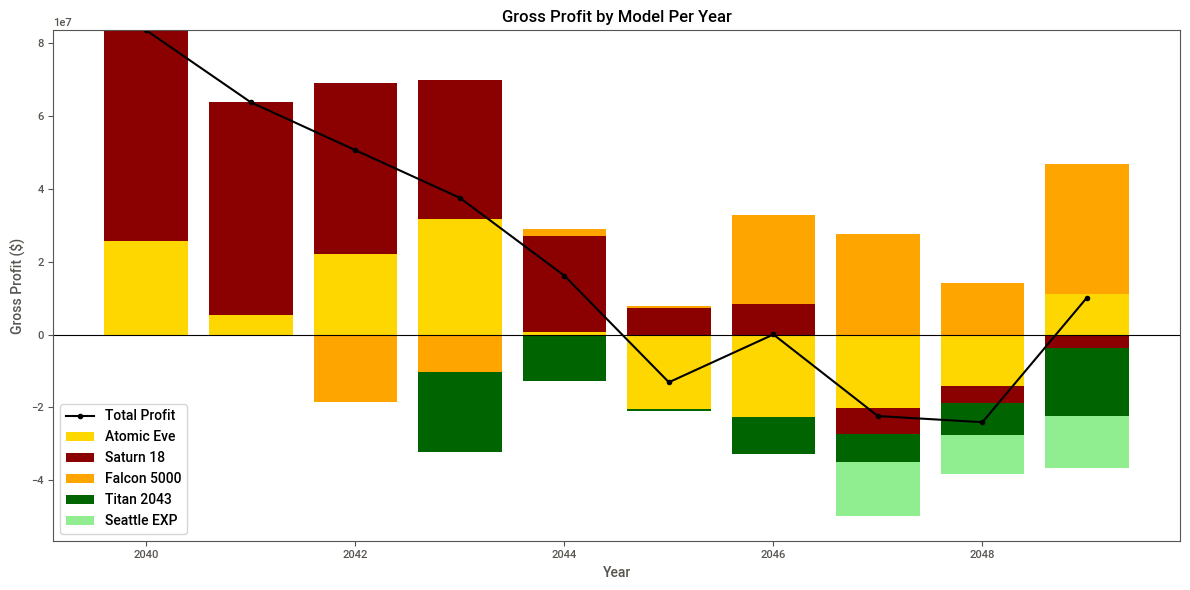

In [85]:
import matplotlib.pyplot as plt

# gross profit by model per year
fig, ax = plt.subplots(figsize=(12, 6))

years = sorted(profitability['year'].unique())
models = profitability['product'].unique()

colors = ['gold', 'darkred', 'orange', 'darkgreen', 'lightgreen']

bottom_pos = [0] * len(years)
bottom_neg = [0] * len(years)

for i, model in enumerate(models):
    vals = []
    for year in years:
        row = profitability[
            (profitability['product'] == model) &
            (profitability['year'] == year)]
        vals.append(row['gross_profit'].values[0] if len(row) > 0 else 0)

    pos = [max(0, v) for v in vals]
    neg = [min(0, v) for v in vals]

    ax.bar(years, pos, bottom=bottom_pos, color=colors[i], label=model)
    ax.bar(years, neg, bottom=bottom_neg, color=colors[i])

    bottom_pos = [a + b for a, b in zip(bottom_pos, pos)]
    bottom_neg = [a + b for a, b in zip(bottom_neg, neg)]

# total profit line
totals = profitability.groupby('year')['gross_profit'].sum()
ax.plot(years, totals.values, color='black', marker='o', label='Total Profit')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Gross Profit by Model Per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Gross Profit ($)')
ax.legend()

plt.tight_layout()
plt.savefig('output/profit_contribution.png', dpi=150)
plt.show()

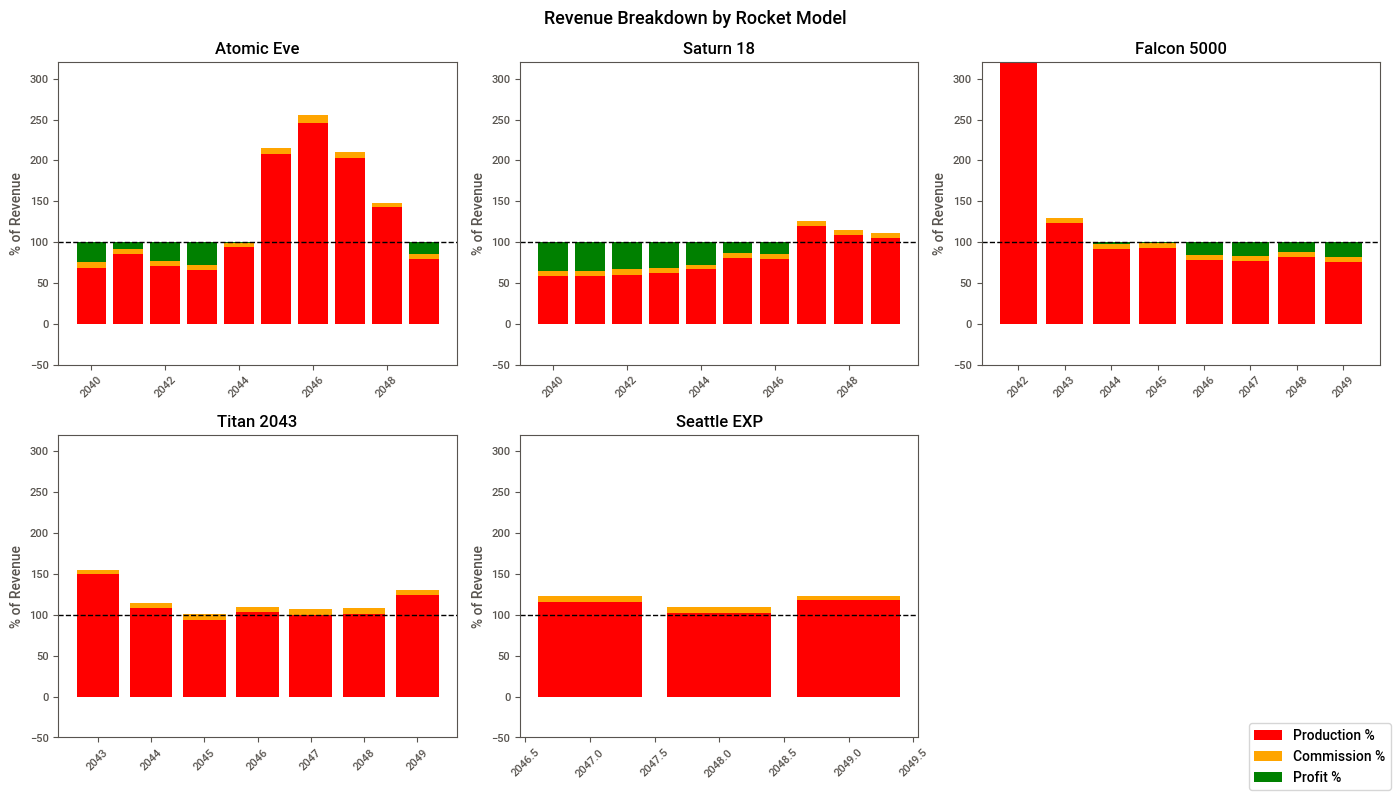

In [86]:
import matplotlib.pyplot as plt

# revenue breakdown per model - production vs commission vs profit
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

models = breakdown['product'].unique()

for i, model in enumerate(models):
    ax = axes_flat[i]
    df = breakdown[breakdown['product'] == model]

    ax.bar(df['year'], df['production_pct'], color='red', label='Production %')
    ax.bar(df['year'], df['commission_pct'], bottom=df['production_pct'], color='orange', label='Commission %')
    ax.bar(df['year'], df['profit_pct'].clip(lower=0),
        bottom=df['production_pct'] + df['commission_pct'],
        color='green', label='Profit %')

    ax.axhline(100, color='black', linestyle='--', linewidth=1)
    ax.set_title(model)
    ax.set_ylabel('% of Revenue')
    ax.set_ylim(-50, 320)
    ax.tick_params(axis='x', rotation=45)

# hide last empty plot
axes_flat[-1].set_visible(False)

# one legend for all
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right')

fig.suptitle('Revenue Breakdown by Rocket Model', fontsize=13)
plt.tight_layout()
plt.savefig('output/revenue_breakdown_by_model.png', dpi=150)
plt.show()

**Revenue Breakdown by Rocket Model**

1. Commission is consistently around 6% across every model every year
2. Production cost is the real issue: when the red bar exceeds  100% line the company is losing money on that model

**Atomic Eve:**
3. Was profitable 2040-2044- production costs below revenue
4. Post 2044 nuclear accident- costs spiraled, sales collapsed
5. Slight recovery in 2049- costs coming back under control

**Saturn 18:**
6. Healthy margins early
7. Creeping above 100% from 2047 onwards- volume declining but fixed costs remaining

**Falcon 5000:**
8. Catastrophic start in 2042- production cost hit 300% of revenue
9. Fastest improvement of any model- down to 75% cost ratio by 2049
10. Only model consistently moving in the right direction- blueprint for others

**Titan 2043:**
11. Never achieved a cost ratio below 100%- not a single profitable year
12. Fundamental production cost problem- not a demand or pricing issue

**Seattle EXP:**
13. Only 3 years of data- still in ramp up phase
14. Costs above 100% but too early to conclude